

# Make inferences using lochNESS predictions on Perturb-seq


You can run this tutorial on Google Colab!  

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1OiMNI7R1SoicIO9YRDoWFLki1e3pJcHL?usp=sharing)


This tutorial demonstrates how to use the pertTF model to make inferences and predictions on Perturb-seq data. Specifically, it shows how to use a pre-trained model (trained with lochNESS awareness) to predict the effects of perturbing specific genes, even if those genes were not explicitly seen during training.

**Brief Description**

The notebook guides you through setting up the environment, loading a pre-trained model, and applying it to a CRISPRi-based Perturb-seq dataset. It focuses on predicting the transcriptional changes and "lochNESS scores" for specific gene perturbations (like the essential gene MRPS5 and the transcription factor CTNNB1). It then validates these predictions by comparing the predicted downstream gene expression changes (using GSEA) with the actual experimental data.

**Main Tasks Performed in this Tutorial:**

- Environment Setup & Model Loading: Installs necessary packages (pertTF, scanpy, etc.) and downloads a pre-trained PerturbationTFModel.
- Data Preparation: Downloads a demo CRISPRi Perturb-seq dataset from Hugging Face and preprocesses it.
- Baseline Analysis: Explores the actual experimental data for CTNNB1 perturbation, performing Gene Set Enrichment Analysis (GSEA) to identify affected pathways.
- In Silico Perturbation (MRPS5): Simulates the perturbation of an unseen essential gene (MRPS5) on Wild Type (WT) cells and evaluates the predicted lochNESS scores.
- In Silico Perturbation & Validation (CTNNB1):

    *    Simulates the perturbation of CTNNB1 on WT cells.
    *   Performs GSEA on the predicted high-confidence perturbed cells.
    *   Compares the enriched pathways from the model's predictions with those from the actual experimental data.

- Embedding Visualization: Plots UMAPs of the predicted cell embeddings to visualize how the model separates different cell states and predicted genotypes.


## environment setup and importing

In [1]:
!python --version


Python 3.12.12


In [2]:
# Specifically for Google Colab, install dependencies and download data
#from google.colab import drive
#drive.mount('/content/drive')

import os
import sys
#%load_ext autoreload
#%autoreload 2

!pip install scanpy flash-attn #--no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 104.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 12.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 166.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 32.6 MB/s eta 0:00:00
  Created wheel for flash-attn: filename=flash_attn-2.8.3-cp312-cp312-linux_x86_64.whl size=256040057 sha256=f25da18657a87fc83dc1bfb8b7751b82246e9db355510226b674fd

In [3]:
import copy
import gc
import json
import os
from pathlib import Path
import sys
import time
import traceback
from typing import List, Tuple, Dict, Union, Optional
import warnings
import random

import torch
from anndata import AnnData
import scanpy as sc
import numpy as np
#import scvi
import wandb
from scipy.sparse import issparse
import matplotlib.pyplot as plt
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

sc.set_figure_params(figsize=(4, 4))
os.environ["KMP_WARNINGS"] = "off"
warnings.filterwarnings('ignore')


## Install pertTF

In [4]:
# clone main branch
#!git clone https://github.com/davidliwei/pertTF.git
#sys.path.insert(0, '/content/pertTF/')

# use test pyPI
#!pip install -i https://test.pypi.org/simple/ pertTF

# use pypi
!pip install pertTF


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 216.4 kB/s eta 0:00:00


In [5]:
#sys.path.insert(0, '/content/pertTF/')


from perttf.model.pertTF import PerturbationTFModel
from perttf.model.config_gen import generate_config
from perttf.model.train_data_gen import produce_training_datasets
from perttf.model.train_function import train,wrapper_train,eval_testdata
from perttf.model.pert_emb import generate_pert_embeddings, calculate_avg_cosine_similarity
#from perttf.utils


✅ Detected Flash Attention v2.


## load the configuration and the data

download the previously trained model for reproducibility. The model need to be trained in a lochNESS aware manner (see previous tutorials).

The file can be found on https://drive.google.com/file/d/1uPVHlkQ3zh4Fny8dpTxZ40U5MmVqHI84/view?usp=sharing

In [6]:


#model_path=Path(f'/content/drive/MyDrive/Colab Notebooks/scGPT/pancreatic_integrated/virtual_screen/others/results/dev_virtual_screen_training_lochness_test_add_PS-Apr07-18-12/second_round') #

import os

# Install gdown if not already installed
!pip install -q gdown

file_id = '1uPVHlkQ3zh4Fny8dpTxZ40U5MmVqHI84'  #
output_filename = 'dev_virtual_screen_training_lochness_test_add_PS-Apr07-18-12' #

# Construct the download URL
url = f'https://drive.google.com/uc?id={file_id}'

# Download the file using gdown
!gdown --id {file_id} -O {output_filename}

if os.path.exists(output_filename):
    print(f"File '{output_filename}' downloaded successfully!")
else:
    print(f"Failed to download '{output_filename}'. Please check the file ID and permissions.")


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1uPVHlkQ3zh4Fny8dpTxZ40U5MmVqHI84
From (redirected): https://drive.google.com/uc?id=1uPVHlkQ3zh4Fny8dpTxZ40U5MmVqHI84&confirm=t&uuid=793b72bf-47c5-4b10-aa92-0edb9ddd184a
To: /content/dev_virtual_screen_training_lochness_test_add_PS-Apr07-18-12
100% 257M/257M [00:05<00:00, 46.7MB/s]
File 'dev_virtual_screen_training_lochness_test_add_PS-Apr07-18-12' downloaded successfully!


In [7]:
!tar -xzf {output_filename}
# Remove .gz and .tar extensions using string replacement
output_filebase = output_filename.replace('.tar.gz', '')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path=Path(f'/content/{output_filebase}/second_round') #

In [8]:
vocab=torch.load(model_path / 'vocab.pt', weights_only=False)

#genes = adata.var["gene_name"].tolist()

#gene_ids = np.array(vocab(genes), dtype=int)
#gene_ids

In [9]:
# load the running parameters
running_parameters=torch.load(model_path / 'running_parameters.pt', weights_only=False)
running_parameters.keys()

cell_type_to_index = running_parameters['cell_type_to_index']
genotype_to_index = running_parameters['genotype_to_index']
genes = running_parameters['genes']
gene_ids = running_parameters['gene_ids']

n_perturb=len(genotype_to_index)
num_batch_types = 1
n_cls=len(cell_type_to_index)
n_ps = len(running_parameters['ps_names'])

In [10]:
import json
hyperparameter_lastrun=json.load(open(model_path / 'config.json','r'))

hyperparameter_lastrun['dataset_name']='virtual_screen_validation'
hyperparameter_lastrun

{'seed': 42,
 'gears_path': '/content/drive/MyDrive/Colab Notebooks/scGPT/gears_tutorial/results/gears_gwps-Mar25-03-38/best_model',
 'save_path': '/content/drive/MyDrive/Colab Notebooks/scGPT/pancreatic_integrated/virtual_screen/others/results/',
 'dataset_name': 'virtual_screen_validation',
 'do_train': True,
 'load_model': None,
 'GEPC': True,
 'ecs_thres': 0.7,
 'dab_weight': 0.0,
 'this_weight': 1.0,
 'next_weight': 0.0,
 'n_rounds': 10,
 'next_cell_pred_type': 'lochness',
 'ecs_weight': 1.0,
 'cell_type_classifier': True,
 'cell_type_classifier_weight': 1.0,
 'genotype_classifier': True,
 'perturbation_classifier_weight': 1.0,
 'ps_weight': 10,
 'pred_lochness_next': 100,
 'perturbation_input': False,
 'CCE': False,
 'mask_ratio': 0.15,
 'epochs': 20,
 'n_bins': 0,
 'lr': 0.001,
 'batch_size': 128,
 'layer_size': 32,
 'nlayers': 2,
 'nhead': 4,
 'dropout': 0.4,
 'schedule_ratio': 0.97,
 'save_eval_interval': 5,
 'log_interval': 100,
 'fast_transformer': False,
 'pre_norm': False,

In [11]:
config, run_session = generate_config(hyperparameter_lastrun,wandb_mode="disabled")


wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.


{'seed': 42, 'gears_path': '/content/drive/MyDrive/Colab Notebooks/scGPT/gears_tutorial/results/gears_gwps-Mar25-03-38/best_model', 'save_path': '/content/drive/MyDrive/Colab Notebooks/scGPT/pancreatic_integrated/virtual_screen/others/results/', 'dataset_name': 'virtual_screen_validation', 'do_train': True, 'load_model': None, 'GEPC': True, 'ecs_thres': 0.7, 'dab_weight': 0.0, 'this_weight': 1.0, 'next_weight': 0.0, 'n_rounds': 10, 'next_cell_pred_type': 'lochness', 'ecs_weight': 1.0, 'cell_type_classifier': True, 'cell_type_classifier_weight': 1.0, 'genotype_classifier': True, 'perturbation_classifier_weight': 1.0, 'ps_weight': 10, 'pred_lochness_next': 100, 'perturbation_input': False, 'CCE': False, 'mask_ratio': 0.15, 'epochs': 20, 'n_bins': 0, 'lr': 0.001, 'batch_size': 128, 'layer_size': 32, 'nlayers': 2, 'nhead': 4, 'dropout': 0.4, 'schedule_ratio': 0.97, 'save_eval_interval': 5, 'log_interval': 100, 'fast_transformer': False, 'pre_norm': False, 'amp': True, 'do_sample_in_train':

In [12]:

save_dir = Path(f"./save/dev_{config.dataset_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"save to {save_dir}")

#scg.utils.add_file_handler(scg.logger, save_dir / "run.log")

save to save/dev_virtual_screen_validation-Apr20-20-48


## load the model

In [13]:

ntokens = len(vocab)  # size of vocabulary
model = PerturbationTFModel(
    n_perturb, # number of perturbation labels
    3, # layers
    n_ps, # nps
    ntokens,
    config.layer_size, # embsize,
    config.nhead, # nhead,
    config.layer_size, #d_hid,
    config.nlayers, #nlayers,
    vocab=vocab,
    dropout= config.dropout, # config.dropout,
    pad_token=config.pad_token,
    pad_value=config.pad_value,
    do_mvc= config.GEPC, # config.GEPC,
    do_dab=True if config.dab_weight>0 else False, # if config.dab_weight >0 else False,
    use_batch_labels= config.use_batch_label, # config.use_batch_label,
    num_batch_labels=num_batch_types,
    domain_spec_batchnorm= config.DSBN, #config.DSBN,
    n_input_bins= config.n_bins, #n_input_bins,
    ecs_threshold= config.ecs_thres, #config.ecs_thres,
    explicit_zero_prob=config.explicit_zero_prob,
    use_fast_transformer= config.fast_transformer, #config.fast_transformer,
    pre_norm= config.pre_norm, #config.pre_norm,
    n_cls=n_cls, # number of cell type labels
    nlayers_cls=3,
    pred_lochness_next = True if config.pred_lochness_next > 0 else False,
    ps_decoder2_nlayer = 5,

)


In [14]:
#model=torch.load(model_path / 'best_model.pt')
import torch

model.load_state_dict(torch.load(model_path / 'model_e16.pt'),strict=False)

model

PerturbationTFModel(
  (encoder): GeneEncoder(
    (embedding): Embedding(5014, 32, padding_idx=0)
    (enc_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  )
  (value_encoder): ContinuousValueEncoder(
    (dropout): Dropout(p=0.4, inplace=False)
    (linear1): Linear(in_features=1, out_features=32, bias=True)
    (activation): ReLU()
    (linear2): Linear(in_features=32, out_features=32, bias=True)
    (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=32, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
        (linear2): Linear(in_features=32, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=

In [15]:
# prompt: freeze all parameters in pert_decoder of model for further training

for param in model.pert_decoder.parameters():
  param.requires_grad = False






## use existing model (without fine tuning) and test on PDX1 (or other genes) perturbation data

### download and check the h5ad file

In [16]:
!pip install huggingface_hub

In [17]:
# first we load in some packages
from huggingface_hub import hf_hub_download, login
import scanpy as sc
import numpy as np

import anndata as ad

# Now download from huggingface a demo dataset
# login(token='YOUR_HF_TOKEN') #try this if download fails
hf_hub_download(repo_id="weililab/CRISPRI_50TF", filename="./tf50_mixscape_new.h5ad", repo_type='dataset', local_dir='./')
adata = sc.read_h5ad("./tf50_mixscape_new.h5ad")


./tf50_mixscape_new.h5ad:   0%|          | 0.00/3.89G [00:00<?, ?B/s]

In [18]:
adata.obs
adata.obs.genotype.value_counts()

,count
genotype,
non-target,8736
CD81.2,3617
TCF12,3599
ARID1B,3468
AFF4,3123
...,...
EZH2,609
JARID2,589
SUZ12,487


In [19]:
# Rename 'non-target' entries to 'WT' in the genotype column
adata.obs['genotype'] = adata.obs['genotype'].replace('non-target', 'WT')

# Verify the change
print(adata.obs['genotype'].value_counts().head())

genotype
WT        8736
CD81.2    3617
TCF12     3599
ARID1B    3468
AFF4      3123
Name: count, dtype: int64


In [20]:
#adata = ad.AnnData(X=adata.raw.X, obs=adata.obs, var=adata.raw.var)

# preprocess the data
# log normalized expression data needs to be moved to layer under name 'X_binned'
adata.layers['X_binned'] = adata.X
# find highly variable genes (model expects a highly_variable col in adata.var)
sc.pp.highly_variable_genes(adata, n_top_genes=5000)

In [21]:
adata_full = adata

In [22]:
running_parameters['ps_names']

['lonESS_score_NEUROG3',
 'lonESS_score_HHEX',
 'lonESS_score_RFX6',
 'lonESS_score_GATA4',
 'lonESS_score_GATA6',
 'lonESS_score_FOXA2',
 'lonESS_score_NEUROD1',
 'lonESS_score_PAX6',
 'lonESS_score_PBX1',
 'lonESS_score_TADA2B',
 'lonESS_score_TLE3']

### check CTNNB1 gene

In [23]:
adata_cp=adata[adata.obs.genotype.isin(['WT','CTNNB1'])]
adata_cp.obs.genotype.value_counts()

,count
genotype,
WT,8736
CTNNB1,1022


In [24]:

sc.pp.neighbors(adata_cp, )
sc.tl.umap(adata_cp, min_dist=0.3)


You should be able to see CTNNB1 that forms a different cluster with stronger PS scores

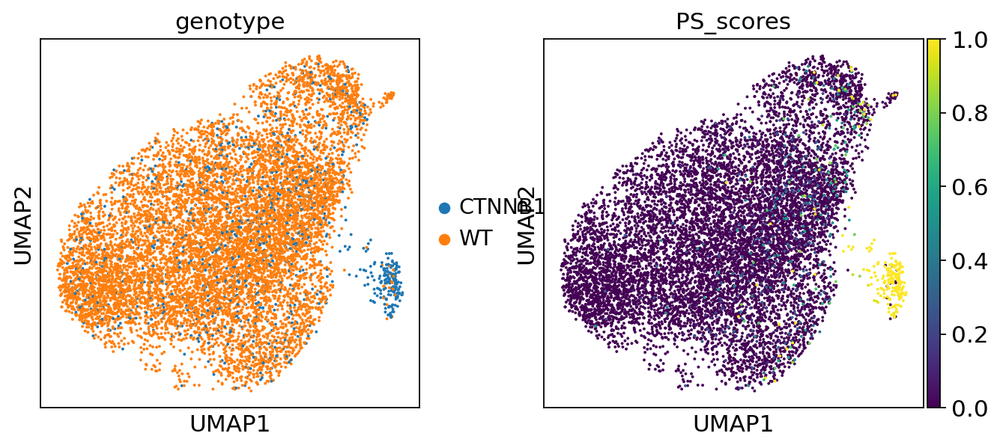

In [25]:
adata_cp.obs['PS_scores']=adata_cp.obsm['PS_scores']['CTNNB1']
sc.pl.umap(adata_cp,color=['genotype','PS_scores'])

### GSEA of CTNNB1-specific clusters
The following is the GSEA analysis to show the gene expression changes of CTNNB1-specific clusters

In [26]:
!pip install gseapy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 25.3 MB/s eta 0:00:00


In [27]:
import scanpy as sc
import gseapy as gp
import numpy as np
import pandas as pd

# 1. Group cells based on ps_pred_next value
adata_cp.obs['group'] = np.where( (adata_cp.obs['PS_scores'] > 0.5) & (adata_cp.obs['genotype'].isin(['CTNNB1'])), 'group1', 'group2')

# 2. Perform differential expression using scanpy
# Using 't-test' (or 'wilcoxon')
sc.tl.rank_genes_groups(adata_cp, 'group', groups=['group1'], reference='group2', method='wilcoxon')

# Extract DE results into a DataFrame
result = adata_cp.uns['rank_genes_groups']
groups = result['names'].dtype.names
diff_exp_df = pd.DataFrame(
    {
        'names': result['names'][groups[0]],
        'scores': result['scores'][groups[0]],
        'pvals': result['pvals'][groups[0]],
        'pvals_adj': result['pvals_adj'][groups[0]],
        'logfoldchanges': result['logfoldchanges'][groups[0]]
    }
)

# 3. Identify top highly expressed genes (e.g., top 200 by score)
top_genes = diff_exp_df.sort_values('scores', ascending=False).head(200)['names'].tolist()
print(f"Top 10 DE genes: {top_genes[:10]}")

# 4. Run GSEA analysis
# Ensure gseapy is installed: !pip install gseapy
# Using Enrichr for the top gene set
enr = gp.enrichr(gene_list=top_genes,
                 gene_sets=['KEGG_2019_Human', 'GO_Biological_Process_2021'],
                 organism='human',
                 outdir=None)

# Display top enriched pathways
enr.results.head(20)


Top 10 DE genes: ['VIM', 'NTS', 'TMSB4X', 'LDLRAD4', 'CALD1', 'ACTB', 'LEFTY1', 'ROBO2', 'SIPA1L2', 'ARHGAP29']


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2019_Human,Leukocyte transendothelial migration,12/112,1.323607e-09,2.845756e-07,0,0,12.574468,257.058656,RAP1B;ITGB1;VAV3;MSN;THY1;RAC1;ACTB;MYL12A;CD9...
1,KEGG_2019_Human,Focal adhesion,13/199,1.098459e-07,1.180844e-05,0,0,7.330861,117.471085,VAV3;ITGB1;JUN;SHC3;ACTB;MYL12A;PTK2;MYL12B;PP...
2,KEGG_2019_Human,Regulation of actin cytoskeleton,13/214,2.551028e-07,1.828237e-05,0,0,6.778594,102.909892,VAV3;ITGB1;MSN;ACTB;MYL12A;PTK2;MYL12B;PPP1CA;...
3,KEGG_2019_Human,Bacterial invasion of epithelial cells,8/74,7.446198e-07,4.002332e-05,0,0,12.458333,175.791968,ITGB1;SHC3;ELMO1;CLTA;RAC1;WASF2;ACTB;PTK2
4,KEGG_2019_Human,Human immunodeficiency virus 1 infection,12/212,1.572514e-06,6.761812e-05,0,0,6.255319,83.588796,PPP3CA;JUN;GNG5;AKT3;CFL1;GNB1;RAC1;B2M;PTK2;S...
5,KEGG_2019_Human,Axon guidance,11/181,2.171103e-06,7.779784e-05,0,0,6.720510,87.637307,ITGB1;ROBO2;PPP3CA;CAMK2D;CFL1;UNC5C;RAC1;MYL1...
6,KEGG_2019_Human,Chemokine signaling pathway,11/190,3.476288e-06,1.067717e-04,0,0,6.379681,80.189695,RAP1B;VAV3;SHC3;GNG5;AKT3;GNB1;ELMO1;RAC1;FOXO...
7,KEGG_2019_Human,Proteoglycans in cancer,11/201,5.966431e-06,1.348675e-04,0,0,6.006962,72.259916,ITGB1;CD63;DDX5;CAMK2D;CCND1;AKT3;MSN;RAC1;ACT...
8,KEGG_2019_Human,Relaxin signaling pathway,9/130,6.481527e-06,1.348675e-04,0,0,7.663494,91.552343,JUN;EDNRB;SHC3;SMAD3;GNG5;AKT3;GNB1;CREB5;GNAI2
9,KEGG_2019_Human,Pathways in cancer,18/530,6.735260e-06,1.348675e-04,0,0,3.725790,44.367280,ITGB1;JUN;CAMK2D;SMAD3;MGST3;PTK2;GNAI2;RBX1;E...


In [28]:
diff_exp_df

,names,scores,pvals,pvals_adj,logfoldchanges
0,VIM,17.278999,6.771229e-67,1.081805e-62,4.272461
1,NTS,16.252771,2.134902e-59,1.705413e-55,3.884974
2,TMSB4X,15.974601,1.920800e-57,1.227506e-53,1.137734
3,LDLRAD4,13.227054,6.124114e-40,1.956838e-36,4.468726
4,CALD1,12.084566,1.274418e-33,1.939119e-30,1.420662
...,...,...,...,...,...
31948,ADAMTS19,-13.816159,2.036492e-43,8.134004e-40,-2.370610
31949,HDAC2-AS2,-14.090103,4.369223e-45,1.994426e-41,-2.056502
31950,ENSG00000271860,-15.305261,7.051852e-53,3.755464e-49,-1.761265
31951,SYT1,-16.380693,2.627287e-60,2.798323e-56,-1.898482


In [29]:
enr.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2019_Human,Leukocyte transendothelial migration,12/112,1.323607e-09,2.845756e-07,0,0,12.574468,257.058656,RAP1B;ITGB1;VAV3;MSN;THY1;RAC1;ACTB;MYL12A;CD9...
1,KEGG_2019_Human,Focal adhesion,13/199,1.098459e-07,1.180844e-05,0,0,7.330861,117.471085,VAV3;ITGB1;JUN;SHC3;ACTB;MYL12A;PTK2;MYL12B;PP...
2,KEGG_2019_Human,Regulation of actin cytoskeleton,13/214,2.551028e-07,1.828237e-05,0,0,6.778594,102.909892,VAV3;ITGB1;MSN;ACTB;MYL12A;PTK2;MYL12B;PPP1CA;...
3,KEGG_2019_Human,Bacterial invasion of epithelial cells,8/74,7.446198e-07,4.002332e-05,0,0,12.458333,175.791968,ITGB1;SHC3;ELMO1;CLTA;RAC1;WASF2;ACTB;PTK2
4,KEGG_2019_Human,Human immunodeficiency virus 1 infection,12/212,1.572514e-06,6.761812e-05,0,0,6.255319,83.588796,PPP3CA;JUN;GNG5;AKT3;CFL1;GNB1;RAC1;B2M;PTK2;S...
...,...,...,...,...,...,...,...,...,...,...
1938,GO_Biological_Process_2021,regulation of inflammatory response (GO:0050727),1/206,8.752067e-01,8.772373e-01,0,0,0.480328,0.064025,TMSB4X
1939,GO_Biological_Process_2021,protein transport (GO:0015031),2/369,8.864042e-01,8.879458e-01,0,0,0.534858,0.064494,MACF1;SPTBN1
1940,GO_Biological_Process_2021,organelle assembly (GO:0070925),2/425,9.281779e-01,9.292534e-01,0,0,0.462712,0.034487,DYNLL1;SEPTIN7
1941,GO_Biological_Process_2021,positive regulation of MAPK cascade (GO:0043410),1/274,9.375151e-01,9.380579e-01,0,0,0.359435,0.023192,FERMT2


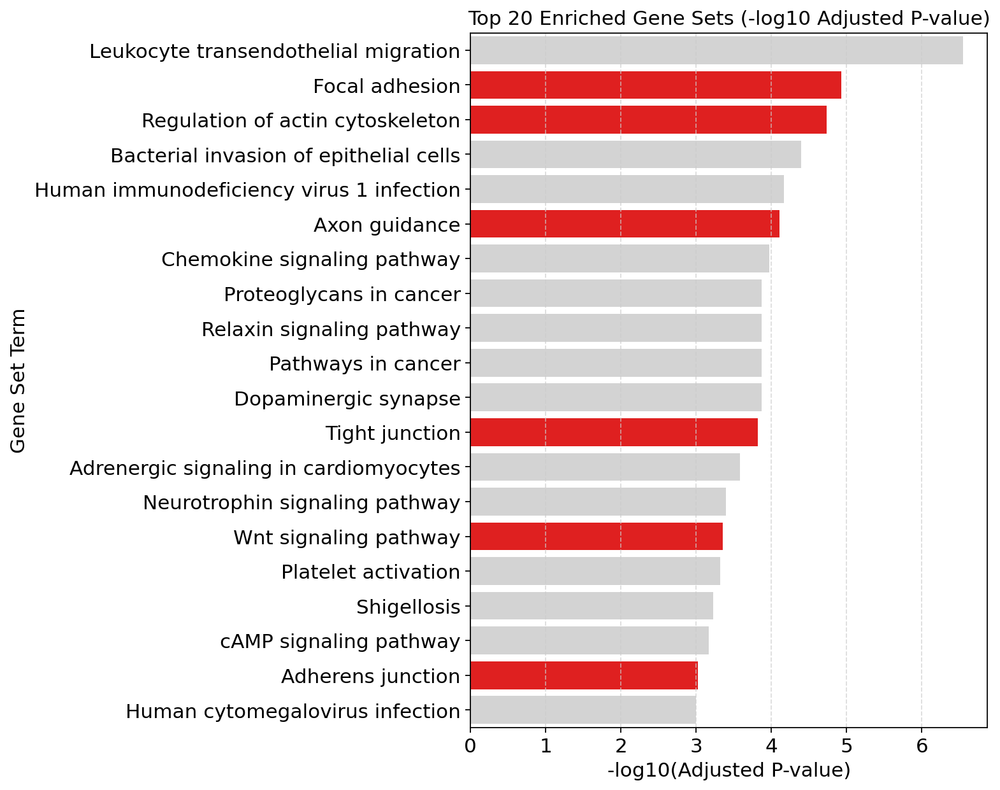

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get top 20 results
plot_df = enr.results.head(20).copy()

# Calculate -log10 Adjusted P-value
plot_df['log_p'] = -np.log10(plot_df['Adjusted P-value'])

# Define target terms for highlighting
target_terms = [
    "Focal adhesion",
    "Regulation of actin cytoskeleton",
    "Axon guidance",
    "Tight junction",
    "Wnt signaling pathway",
    "Adherens junction"
]

# Determine colors: red for targets, grey otherwise
colors = ['red' if term in target_terms else 'lightgrey' for term in plot_df['Term']]

# Create the plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x='log_p',
    y='Term',
    data=plot_df,
    palette=colors,
    hue='Term',
    legend=False
)

plt.title('Top 20 Enriched Gene Sets (-log10 Adjusted P-value)')
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('Gene Set Term')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Plot interesting genes

In [31]:
enr.results[enr.results['Term'].str.contains('Cell cycle')]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
61,KEGG_2019_Human,Cell cycle,5/124,0.008209,0.028467,0,0,4.240681,20.365941,SMAD3;CCND1;YWHAZ;SKP1;RBX1


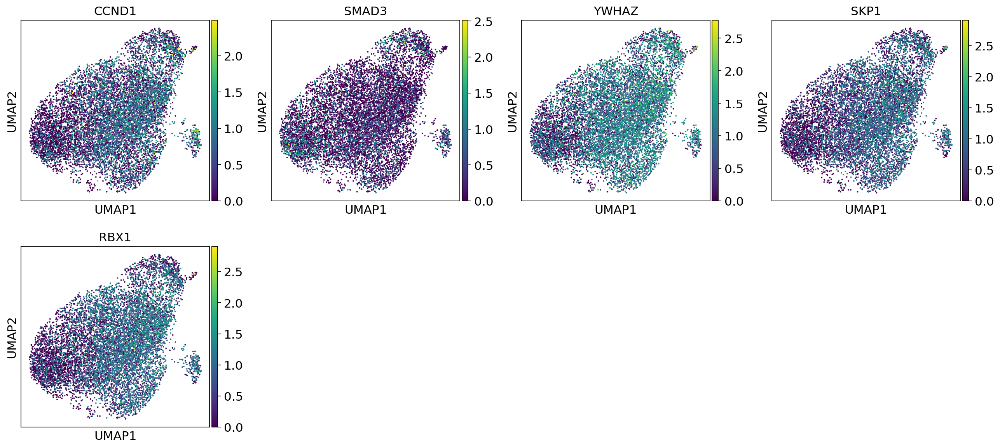

In [32]:
sc.pl.umap(adata_cp,color=['CCND1','SMAD3','YWHAZ','SKP1','RBX1'])

### for a candidate gene, plot the predicted scores

Here we showcase two genes: MRPS5 for essential gene prediction (unseen essential genes), and CTNNB1 prediction (unseen genes)

#### MRPS

In [33]:

target_pred_gene='MRPS5' # ribosomal gene: RPS is in the training dataset


In [34]:
#adata_testrun = adata

if True:
  adata_testrun = adata_full[ (adata_full.obs['genotype'].isin(['WT',target_pred_gene]))
                          ]
  adata_testrun = adata_testrun[adata_testrun.obs['genotype'].isin(genotype_to_index.keys())]
  adata_testrun.obs['genotype_next']= adata_testrun.obs['genotype']  # 'PDX1' # set the next predicted
  adata_testrun




In [35]:
adata_testrun.obs.celltype.value_counts()

,count
celltype,
ESC,8736


In [36]:
adata_testrun.obs.genotype.value_counts()

,count
genotype,
WT,8736


In [37]:
adata_testrun.obs.celltype.value_counts()

,count
celltype,
ESC,8736


Here, randomly assigned WT cells to either WT (not perturbed) or a perturbed gene.

In [38]:
# Ensure that 'WT' and target_pred_gene are in the categories of 'genotype_next'
new_categories = list(adata_testrun.obs['genotype_next'].cat.categories)
if 'WT' not in new_categories:
    new_categories.append('WT')
if target_pred_gene not in new_categories:
    new_categories.append(target_pred_gene)
adata_testrun.obs['genotype_next'] = adata_testrun.obs['genotype_next'].cat.set_categories(new_categories)


adata_testrun.obs.loc[adata_testrun.obs['genotype'].isin(['WT']), 'genotype_next'] = np.random.choice([target_pred_gene,'WT'], size = sum(adata_testrun.obs['genotype'].isin(['WT'])))
adata_testrun.obs.loc[adata_testrun.obs['genotype']=='WT' ,'genotype_next'].value_counts()

,count
genotype_next,
MRPS5,4377
WT,4359


In [39]:
model.to(device)
eval_results = eval_testdata(model, adata_testrun,gene_ids,
                             train_data_dict={"cell_type_to_index":cell_type_to_index,
                                              "genotype_to_index":genotype_to_index,
                                              "vocab":vocab,},
                             config = config)
eval_results

pertTF - INFO - 3848 genes shared between model vocab's 5014 and anndata's 31953 genes
pertTF - INFO - Evaluating data using 1047 tokens for each cell


100%|██████████| 69/69 [00:02<00:00, 27.02it/s]


AnnData object with n_obs × n_vars = 8736 × 3848
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Custom', 'nFeature_Custom', 'percent.mt', 'doublet_score', 'is_doublet_0.08', 'is_doublet_0.10', 'is_doublet_0.15', 'genotype', 'genotype_umis', 'gRNA_detectedGenes', 'genotype_report', 'celltype', 'mixscape_class_global', 'genotype_next', 'predicted_genotype', 'genotype_id', 'predicted_celltype', 'celltype_id'
    var: 'names', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'PS_scores', 'X_scGPT', 'X_scGPT_next', 'ps_pred', 'ps_pred_next', 'X_pert_pred_probs', 'genotype_pred_probs', 'X_cls_pred_probs', 'celltype_pred_probs'
    layers: 'counts_RNA', 'lognorm', 'X_binned'

In [40]:
adata_eva=eval_results #['adata']
adata_eva

AnnData object with n_obs × n_vars = 8736 × 3848
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Custom', 'nFeature_Custom', 'percent.mt', 'doublet_score', 'is_doublet_0.08', 'is_doublet_0.10', 'is_doublet_0.15', 'genotype', 'genotype_umis', 'gRNA_detectedGenes', 'genotype_report', 'celltype', 'mixscape_class_global', 'genotype_next', 'predicted_genotype', 'genotype_id', 'predicted_celltype', 'celltype_id'
    var: 'names', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'PS_scores', 'X_scGPT', 'X_scGPT_next', 'ps_pred', 'ps_pred_next', 'X_pert_pred_probs', 'genotype_pred_probs', 'X_cls_pred_probs', 'celltype_pred_probs'
    layers: 'counts_RNA', 'lognorm', 'X_binned'

In [41]:
adata_eva.obsm['ps_pred_next'].shape
adata_eva.obsm['ps_pred'].shape

(8736, 11)

In [42]:
adata_eva.obsm['celltype_pred_probs'][0,:]

array([5.8787242e-03, 1.1113420e-03, 2.7742023e-03, 1.5666270e-04,
       9.8575717e-01, 2.6985668e-05, 9.6357847e-04, 3.1365129e-05,
       7.4248546e-04, 6.9512060e-04, 2.9758402e-04, 2.1225876e-04,
       4.1789986e-06, 1.3484122e-03], dtype=float32)

In [43]:
cell_type_to_index

{'DE': 0,
 'PFG': 1,
 'PP': 2,
 'PDP': 3,
 'ESC': 4,
 'PGT': 5,
 'SC-alpha': 6,
 'SC-EC': 7,
 'Liver': 8,
 'Endothelial': 9,
 'Stromal': 10,
 'EnP': 11,
 'SC-delta': 12,
 'SC-beta': 13}

In [44]:
sc.pp.neighbors(adata_eva, use_rep="X_scGPT")
sc.tl.umap(adata_eva, min_dist=0.3)

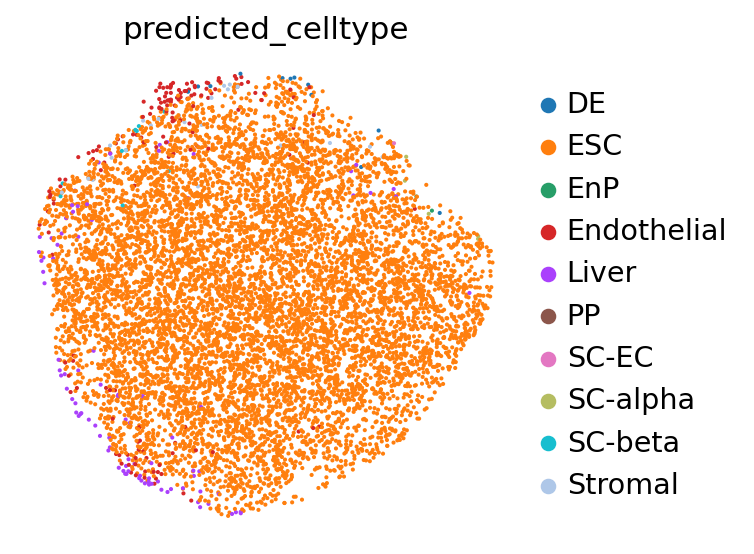

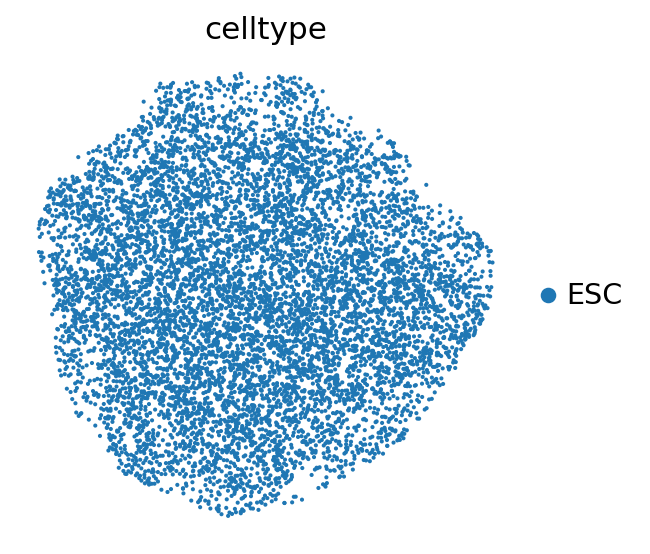

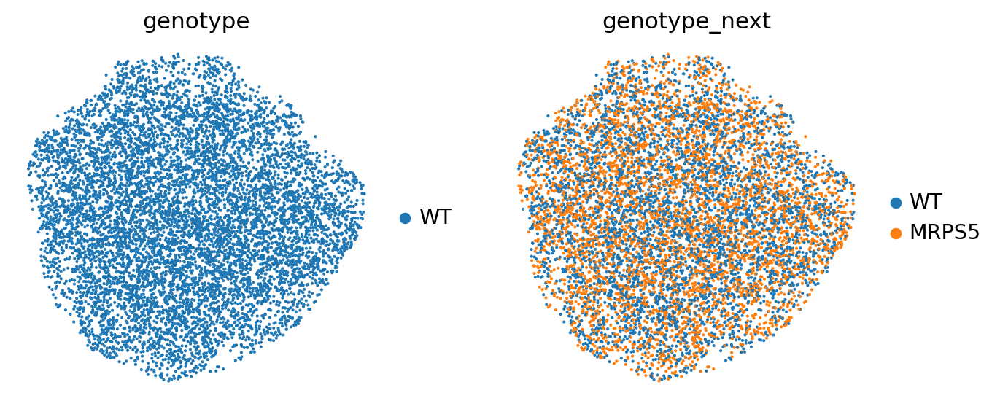

In [45]:
sc.pl.umap(adata_eva,
          color=["predicted_celltype", ],
          frameon=False,

          )
sc.pl.umap(adata_eva,
          color=[ "celltype", ],
          frameon=False,

          )
sc.pl.umap(adata_eva,
          color=[ "genotype","genotype_next"],
          frameon=False,

          )

In [46]:
adata_eva.obs[['genotype','genotype_next']].value_counts()

genotype  genotype_next
WT        MRPS5            4377
          WT               4359
Name: count, dtype: int64

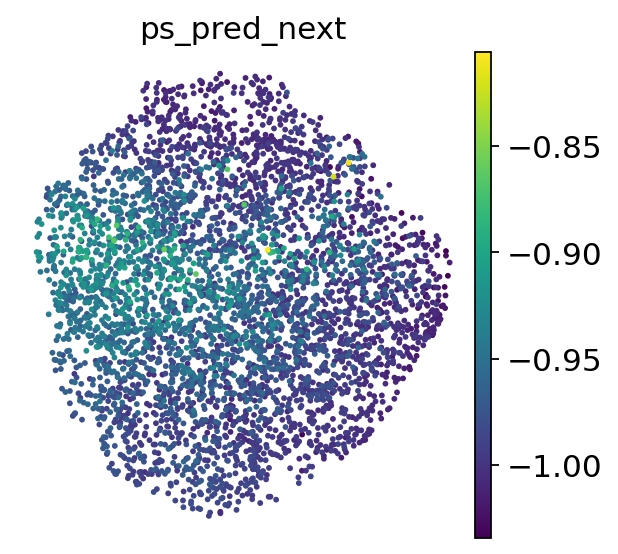

In [47]:
adata_eva.obs['ps_pred_next']=adata_eva.obsm['ps_pred_next']
sc.pl.umap(adata_eva[adata_eva.obs.genotype_next!='WT'], color=[ "ps_pred_next",],frameon=False,)

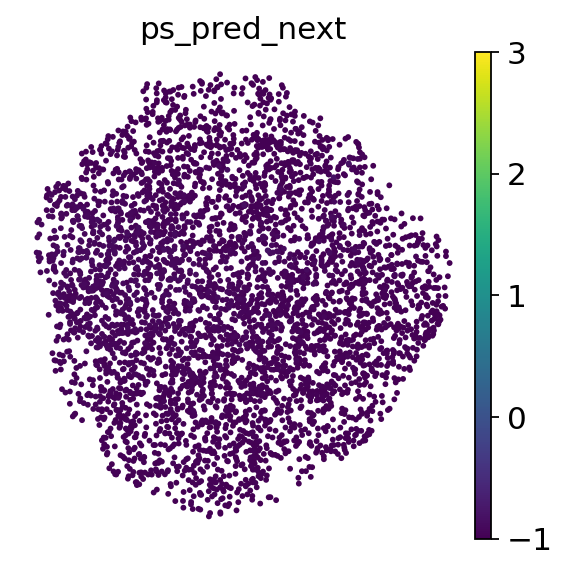

In [48]:
sc.pl.umap(adata_eva[adata_eva.obs.genotype_next!='WT'], color=[ "ps_pred_next",],frameon=False,vmin=-1, vmax=3)

#### CTNNB1

Now, we predict the function of an unseen CTNNB1 gene

In [49]:

target_pred_gene='CTNNB1' # ribosomal gene: RPS is in the training dataset

In [50]:
#adata_testrun = adata

if True:
  adata_testrun = adata_full[ (adata_full.obs['genotype'].isin(['WT',target_pred_gene]))]
  #adata_testrun=adata_full.copy()
  adata_testrun = adata_testrun[adata_testrun.obs['genotype'].isin(genotype_to_index.keys())]
  adata_testrun.obs['genotype_next']= adata_testrun.obs['genotype']  # 'PDX1' # set the next predicted
  adata_testrun




In [51]:
adata_testrun.obs.celltype.value_counts()

,count
celltype,
ESC,9758


In [52]:
adata_testrun.obs.genotype.value_counts()

,count
genotype,
WT,8736
CTNNB1,1022


In [53]:
adata_testrun.obs.genotype_report.value_counts()
#adata_testrun.obs.genotype.value_counts()


,count
genotype_report,
non-target,8736
CTNNB1,1022


Here, we mask cells with actual CTNNB1 perturbation, and treat all cells as "WT" cells. These actual CTNNB1-perturbed cells will be used later for evaluations.

In [54]:
adata_testrun.obs.loc[adata_testrun.obs['genotype']=='CTNNB1','genotype']='WT'

Here, randomly assigned WT cells to either WT (not perturbed) or perturbed cells

In [55]:
# Ensure that 'WT' and target_pred_gene are in the categories of 'genotype_next'
new_categories = list(adata_testrun.obs['genotype_next'].cat.categories)
if 'WT' not in new_categories:
    new_categories.append('WT')
if target_pred_gene not in new_categories:
    new_categories.append(target_pred_gene)
adata_testrun.obs['genotype_next'] = adata_testrun.obs['genotype_next'].cat.set_categories(new_categories)


adata_testrun.obs.loc[adata_testrun.obs['genotype'].isin(['WT']), 'genotype_next'] = np.random.choice([target_pred_gene,'WT'], size = sum(adata_testrun.obs['genotype'].isin(['WT'])))
adata_testrun.obs.loc[adata_testrun.obs['genotype']=='WT' ,'genotype_next'].value_counts()

,count
genotype_next,
CTNNB1,4916
WT,4842


In [56]:
adata_testrun.obs.genotype.value_counts()


,count
genotype,
WT,9758
CTNNB1,0


In [57]:
model.to(device)
eval_results = eval_testdata(model, adata_testrun,gene_ids,
                             train_data_dict={"cell_type_to_index":cell_type_to_index,
                                              "genotype_to_index":genotype_to_index,
                                              "vocab":vocab,},
                             config = config)
eval_results

pertTF - INFO - 3848 genes shared between model vocab's 5014 and anndata's 31953 genes
pertTF - INFO - Evaluating data using 1047 tokens for each cell


100%|██████████| 77/77 [00:01<00:00, 46.88it/s]


AnnData object with n_obs × n_vars = 9758 × 3848
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Custom', 'nFeature_Custom', 'percent.mt', 'doublet_score', 'is_doublet_0.08', 'is_doublet_0.10', 'is_doublet_0.15', 'genotype', 'genotype_umis', 'gRNA_detectedGenes', 'genotype_report', 'celltype', 'mixscape_class_global', 'genotype_next', 'predicted_genotype', 'genotype_id', 'predicted_celltype', 'celltype_id'
    var: 'names', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'PS_scores', 'X_scGPT', 'X_scGPT_next', 'ps_pred', 'ps_pred_next', 'X_pert_pred_probs', 'genotype_pred_probs', 'X_cls_pred_probs', 'celltype_pred_probs'
    layers: 'counts_RNA', 'lognorm', 'X_binned'

In [58]:
adata_eva=eval_results #['adata']
adata_eva

AnnData object with n_obs × n_vars = 9758 × 3848
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Custom', 'nFeature_Custom', 'percent.mt', 'doublet_score', 'is_doublet_0.08', 'is_doublet_0.10', 'is_doublet_0.15', 'genotype', 'genotype_umis', 'gRNA_detectedGenes', 'genotype_report', 'celltype', 'mixscape_class_global', 'genotype_next', 'predicted_genotype', 'genotype_id', 'predicted_celltype', 'celltype_id'
    var: 'names', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    obsm: 'PS_scores', 'X_scGPT', 'X_scGPT_next', 'ps_pred', 'ps_pred_next', 'X_pert_pred_probs', 'genotype_pred_probs', 'X_cls_pred_probs', 'celltype_pred_probs'
    layers: 'counts_RNA', 'lognorm', 'X_binned'

In [59]:
adata_eva.obsm['ps_pred_next'].shape
adata_eva.obsm['ps_pred'].shape

(9758, 11)

In [60]:
adata_eva.obsm['celltype_pred_probs'][0,:]

array([5.6509259e-03, 1.0835126e-03, 2.7326096e-03, 1.5206993e-04,
       9.8626882e-01, 2.5562777e-05, 9.4808964e-04, 3.0714382e-05,
       6.9565116e-04, 6.4023829e-04, 2.8327288e-04, 2.0343692e-04,
       4.0367268e-06, 1.2810610e-03], dtype=float32)

In [61]:
cell_type_to_index

{'DE': 0,
 'PFG': 1,
 'PP': 2,
 'PDP': 3,
 'ESC': 4,
 'PGT': 5,
 'SC-alpha': 6,
 'SC-EC': 7,
 'Liver': 8,
 'Endothelial': 9,
 'Stromal': 10,
 'EnP': 11,
 'SC-delta': 12,
 'SC-beta': 13}

In [62]:
sc.pp.neighbors(adata_eva, use_rep="X_scGPT")
sc.tl.umap(adata_eva, min_dist=0.3)

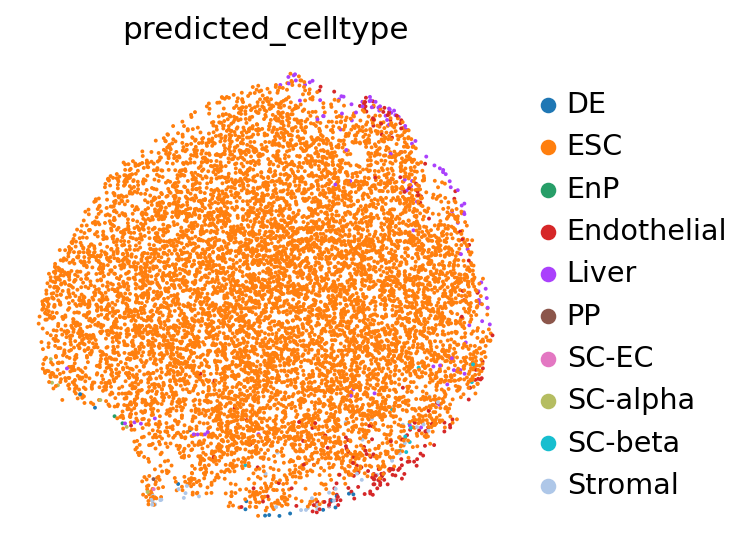

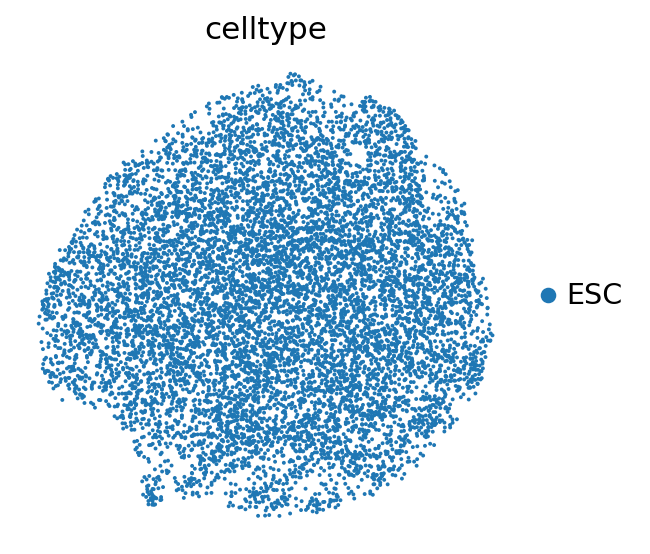

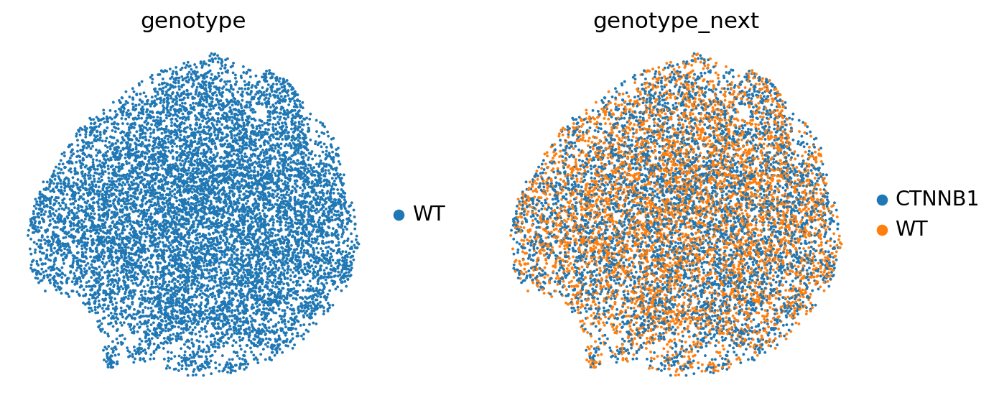

In [63]:
sc.pl.umap(adata_eva,
          color=["predicted_celltype",  ],
          frameon=False,

          )
sc.pl.umap(adata_eva,
          color=[ "celltype", ],
          frameon=False,

          )
sc.pl.umap(adata_eva,
          color=[ "genotype","genotype_next"],
          frameon=False,

          )

In [64]:
adata_eva.obs.predicted_celltype.value_counts() # should be over 96% correct

,count
predicted_celltype,
ESC,9377
Endothelial,190
Liver,110
Stromal,43
DE,16
SC-beta,12
SC-alpha,6
EnP,2
PP,1


In [65]:
adata_eva.obsm['ps_pred'].shape

(9758, 11)

In [66]:
running_parameters['ps_names']

['lonESS_score_NEUROG3',
 'lonESS_score_HHEX',
 'lonESS_score_RFX6',
 'lonESS_score_GATA4',
 'lonESS_score_GATA6',
 'lonESS_score_FOXA2',
 'lonESS_score_NEUROD1',
 'lonESS_score_PAX6',
 'lonESS_score_PBX1',
 'lonESS_score_TADA2B',
 'lonESS_score_TLE3']

Here we plot the lochNESS scores of perturbed genes that are present in the training dataset.

In [67]:
adata_eva.obs[running_parameters['ps_names']]=adata_eva.obsm['ps_pred']

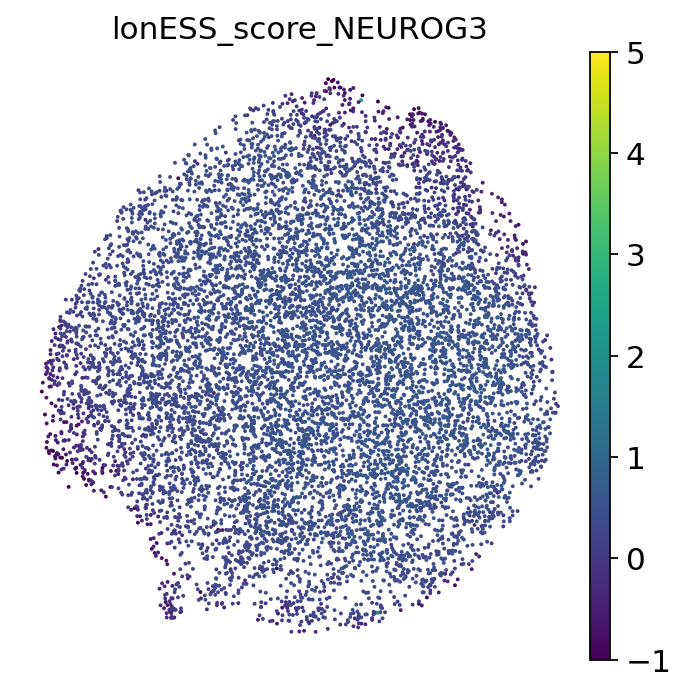

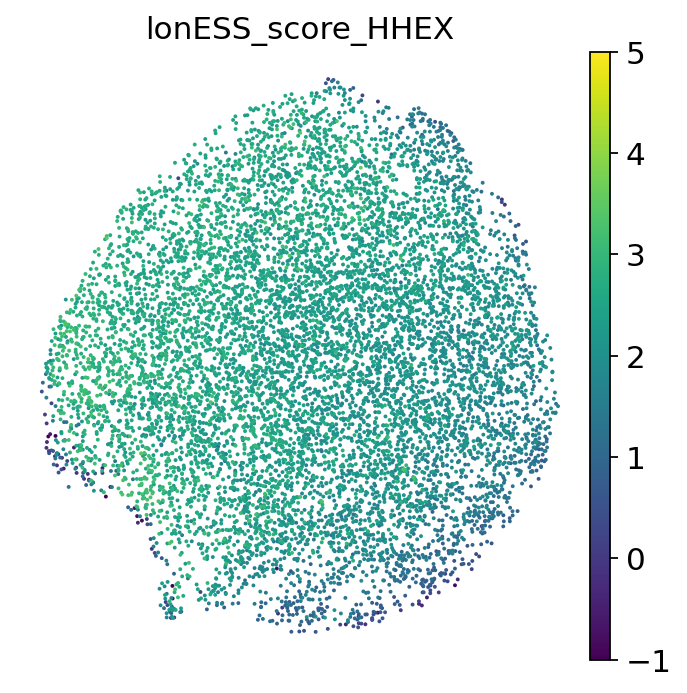

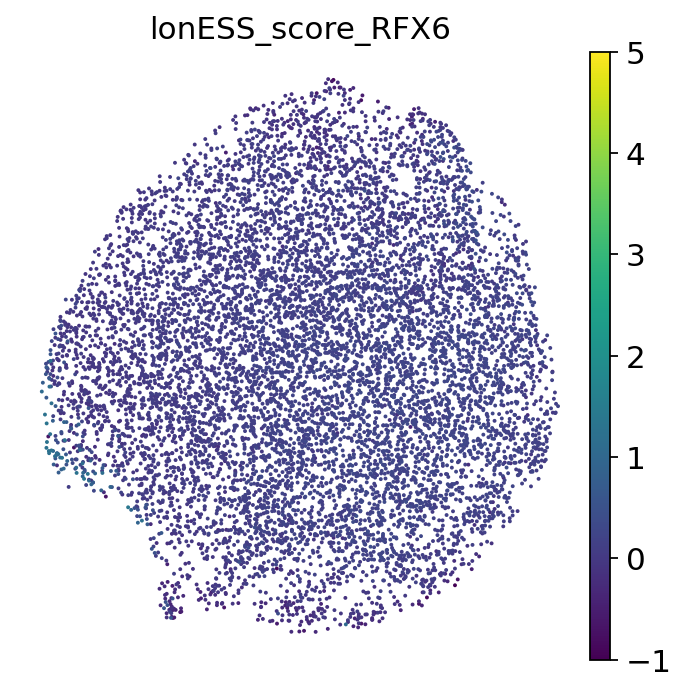

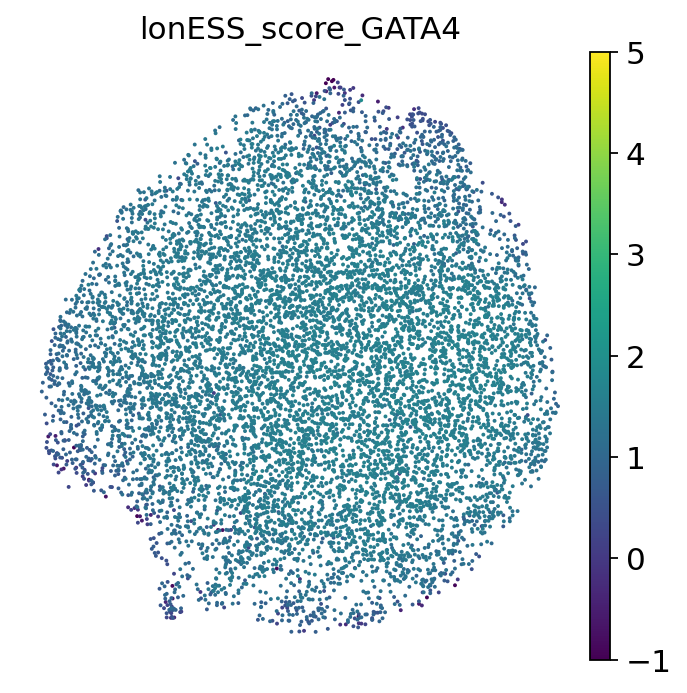

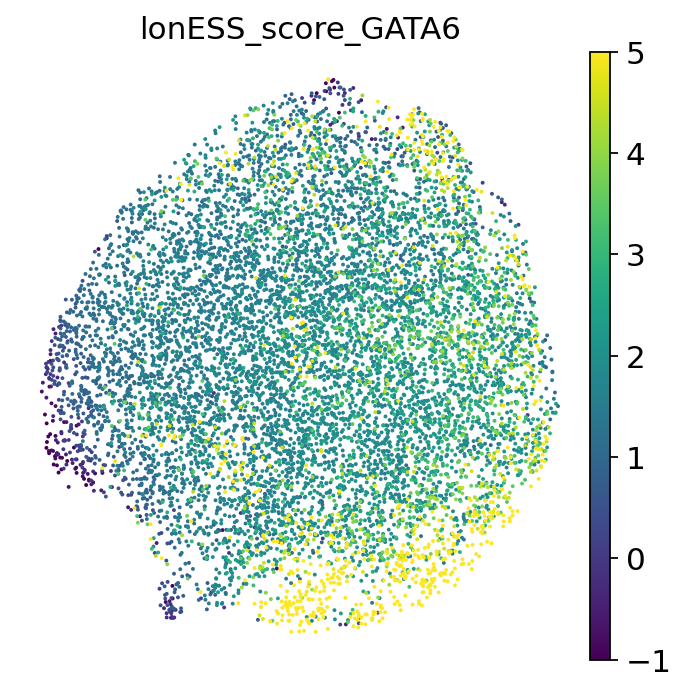

...

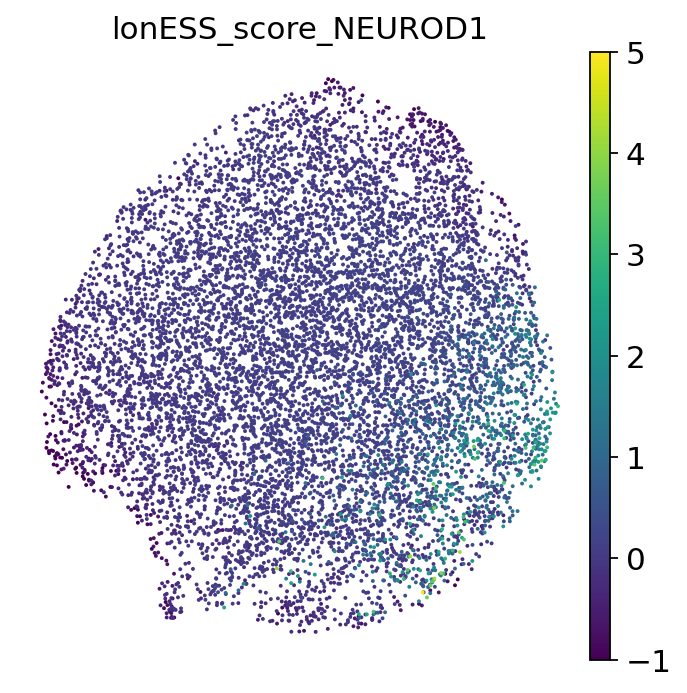

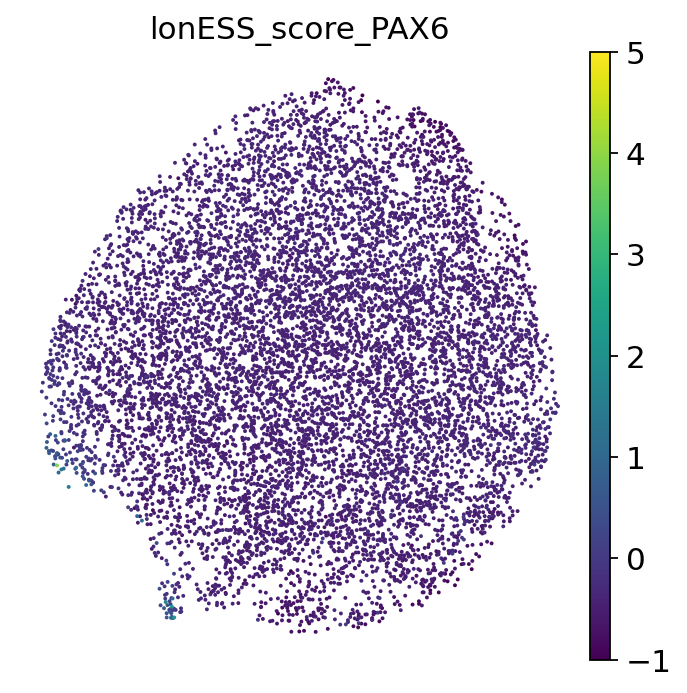

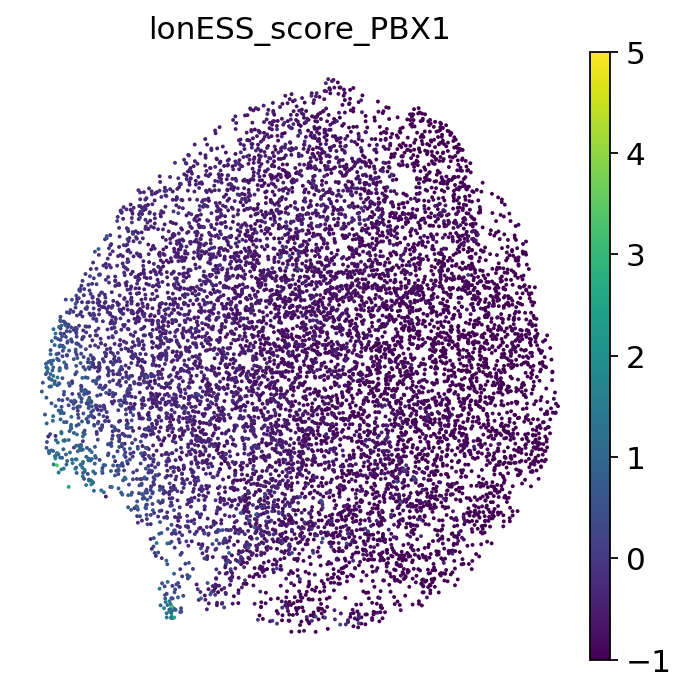

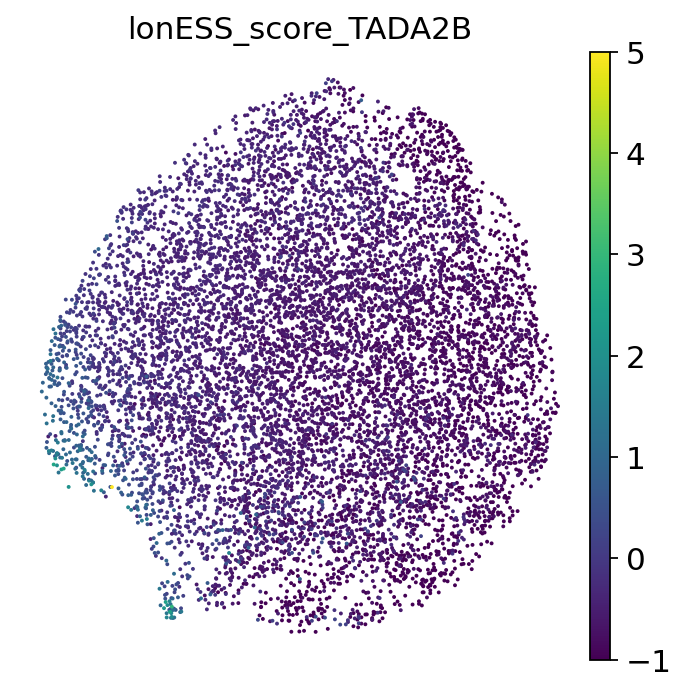

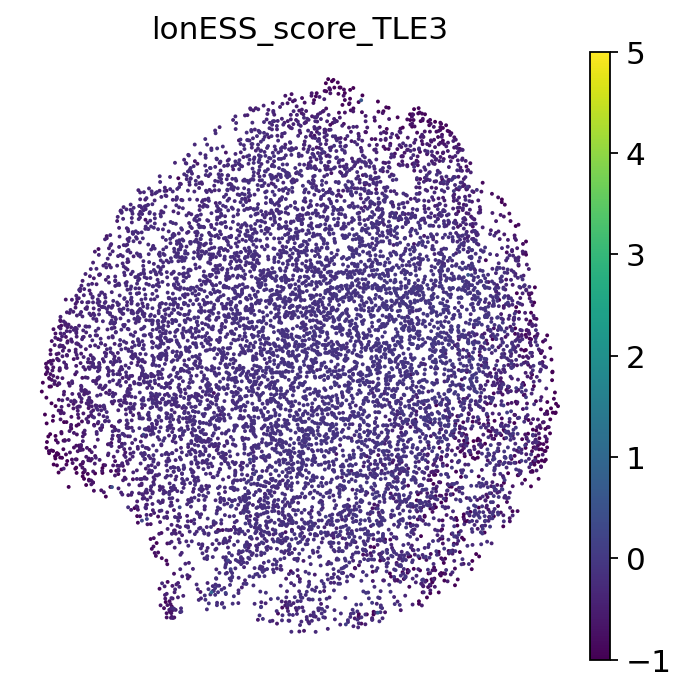

In [68]:
for ps_name in running_parameters['ps_names']:
  with plt.rc_context({"figure.figsize": (5, 5)}):
    sc.pl.umap(adata_eva, color=[ps_name],frameon=False,vmin=-1, vmax=5)

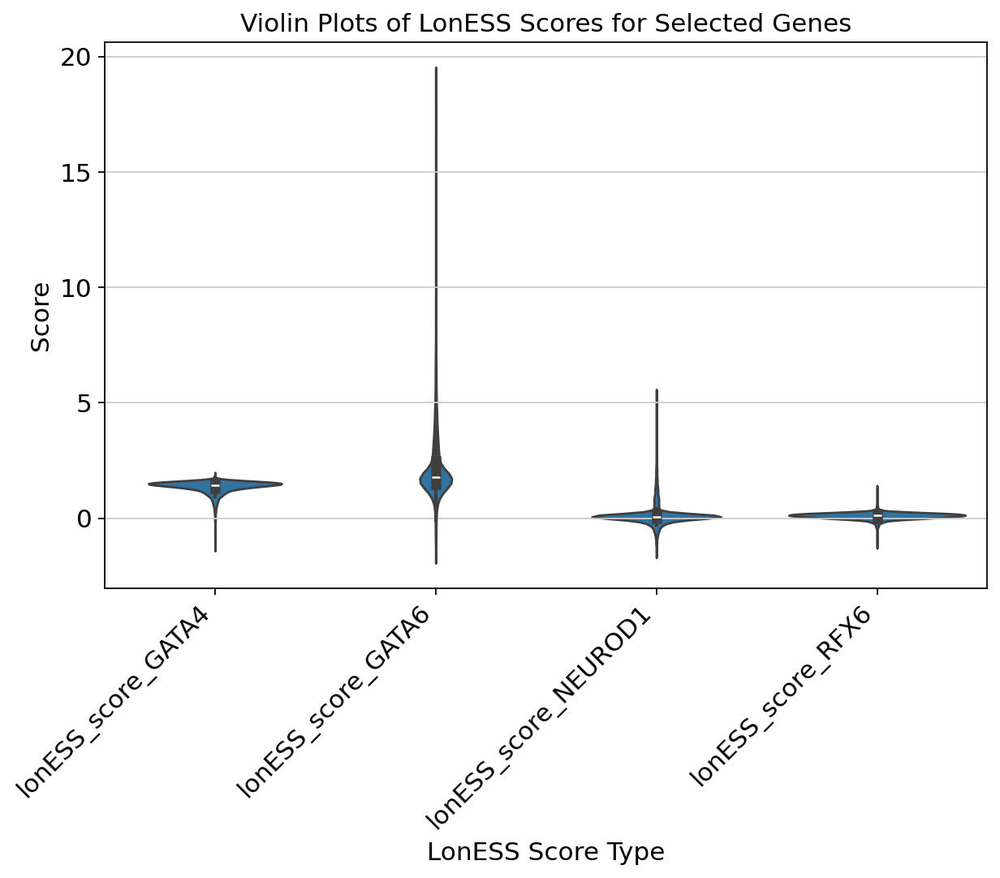

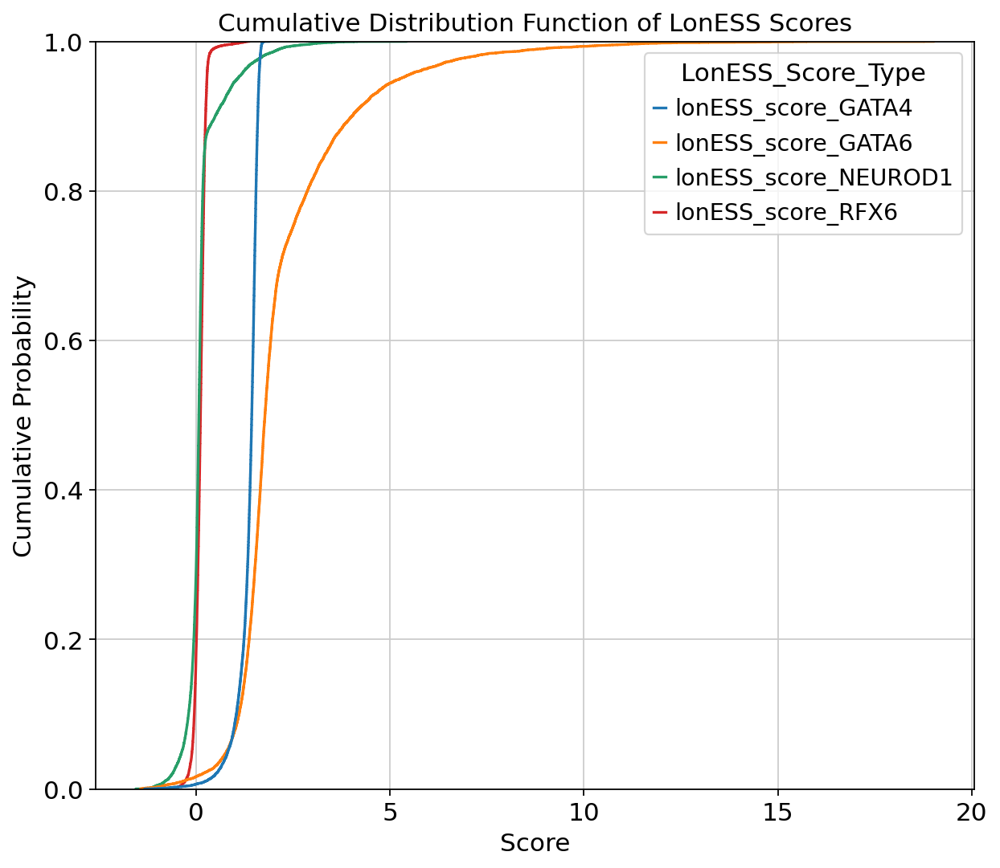

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
plot_data = adata_eva.obs[['lonESS_score_GATA4','lonESS_score_GATA6', 'lonESS_score_NEUROD1','lonESS_score_RFX6',]] #

# Reshape the DataFrame to a long format for plotting multiple violins
plot_data_long = plot_data.melt(var_name='LonESS_Score_Type', value_name='Score')

plt.figure(figsize=(8, 7))
sns.violinplot(x='LonESS_Score_Type', y='Score', data=plot_data_long, inner='box')
plt.title('Violin Plots of LonESS Scores for Selected Genes')
plt.xlabel('LonESS Score Type')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.ylim(-1, 5)
plt.show()

plt.figure(figsize=(8, 7))
sns.ecdfplot(x='Score', hue='LonESS_Score_Type', data=plot_data_long)
plt.title('Cumulative Distribution Function of LonESS Scores')
plt.xlabel('Score')
plt.ylabel('Cumulative Probability')
plt.tight_layout()
plt.show()

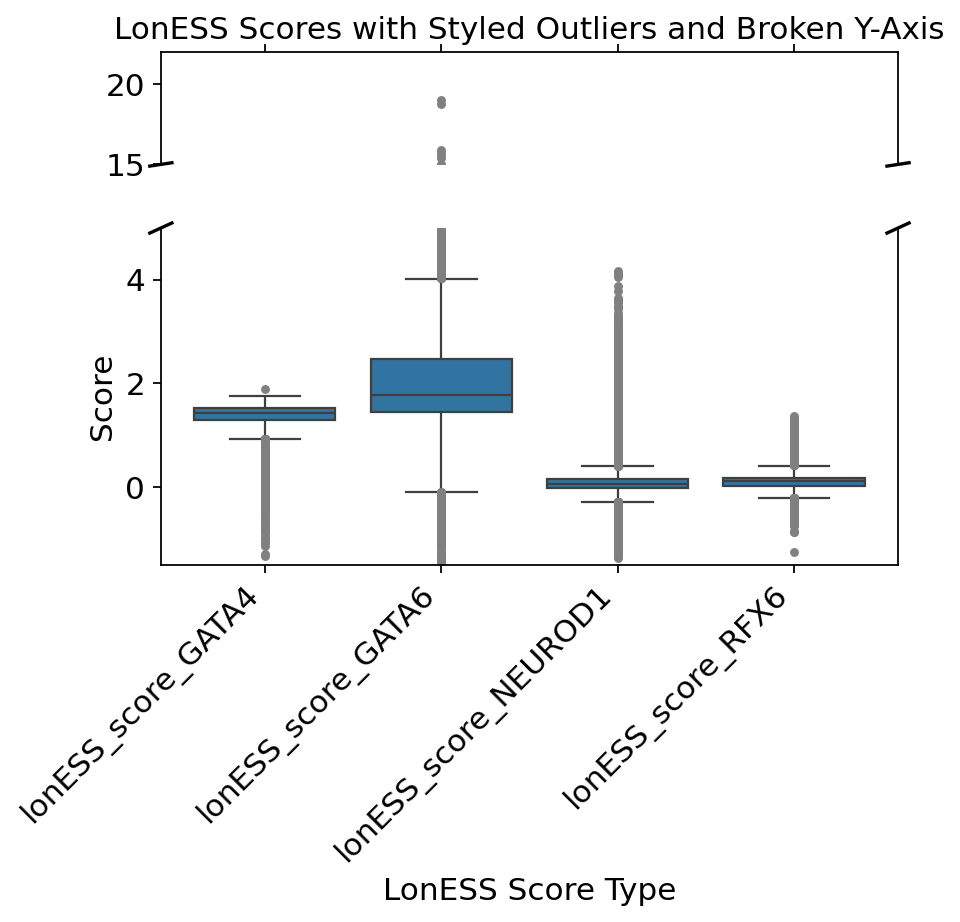

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots sharing the x-axis
f, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(6, 6),
                                     gridspec_kw={'height_ratios': [1, 3]})

# Define the style for the fliers (outliers)
flierprops = dict(marker='o', markerfacecolor='grey', markersize=3,
                  linestyle='none', markeredgecolor='grey')

# Plot boxplots with outliers styled as solid grey dots
sns.boxplot(x='LonESS_Score_Type', y='Score', data=plot_data_long, ax=ax_top, showfliers=True, flierprops=flierprops)
sns.boxplot(x='LonESS_Score_Type', y='Score', data=plot_data_long, ax=ax_bottom, showfliers=True, flierprops=flierprops)

# Set the y-limits for both subplots to create the break
ax_top.set_ylim(15, 22)    # Upper part
ax_bottom.set_ylim(-1.5, 5) # Bottom part

# Remove grid lines
ax_top.grid(False)
ax_bottom.grid(False)

# Hide the spines between the subplots
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.xaxis.tick_top()
ax_top.tick_params(labeltop=False)
ax_bottom.xaxis.tick_bottom()

# Add the diagonal cut-out marks
d = .015
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs) # bottom-right diagonal

# Labels and titles
ax_top.set_title('LonESS Scores with Styled Outliers and Broken Y-Axis')
ax_bottom.set_xlabel('LonESS Score Type')
ax_bottom.set_ylabel('Score')
ax_top.set_ylabel('')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [71]:
from scipy.stats import ks_2samp

# Define the two groups based on the obs columns
group1_cols = ['lonESS_score_GATA4', 'lonESS_score_GATA6']
group2_cols = ['lonESS_score_NEUROD1', 'lonESS_score_RFX6']

# Flatten the values from the specified columns for each group
group1_values = adata_eva.obs[group1_cols].values.flatten()
group2_values = adata_eva.obs[group2_cols].values.flatten()

# Perform the Kolmogorov-Smirnov test
ks_stat, p_value = ks_2samp(group1_values, group2_values)

print(f"Group 1: {', '.join(group1_cols)}")
print(f"Group 2: {', '.join(group2_cols)}")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4e}")

Group 1: lonESS_score_GATA4, lonESS_score_GATA6
Group 2: lonESS_score_NEUROD1, lonESS_score_RFX6
KS Statistic: 0.9216
P-value: 0.0000e+00


Predict the CTNNB1 lochNESS score, which is not in the existing prediciton head. Instead, the score is stored in the "ps_pred_next" output of pertTF.

In [72]:
adata_eva.obs[['genotype','genotype_next']].value_counts()

genotype  genotype_next
WT        CTNNB1           4916
          WT               4842
Name: count, dtype: int64

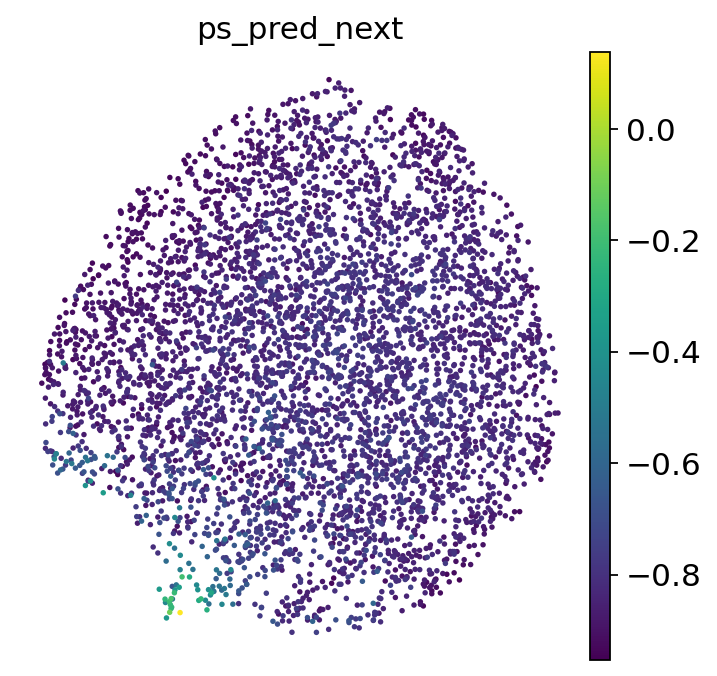

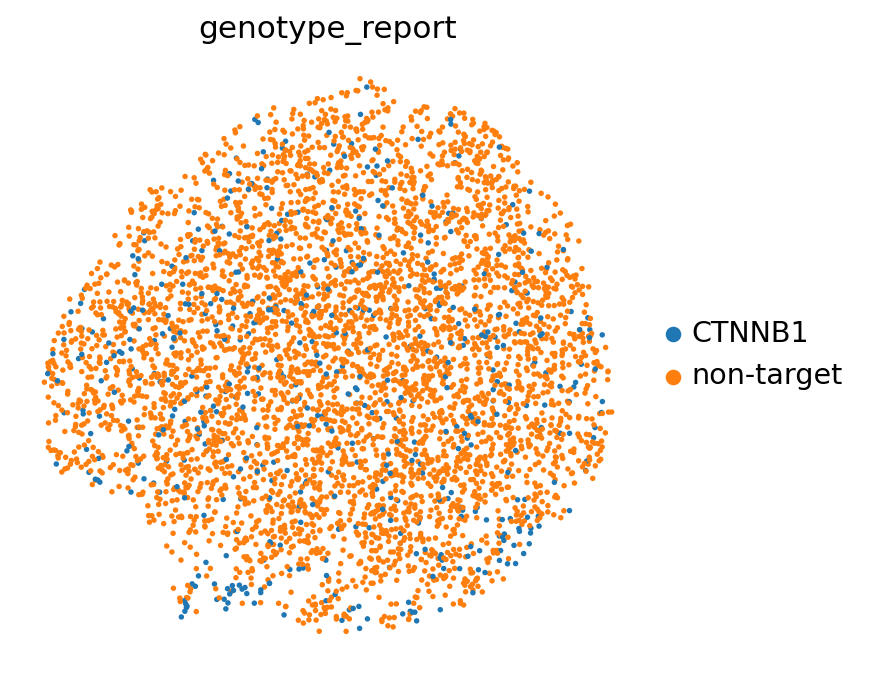

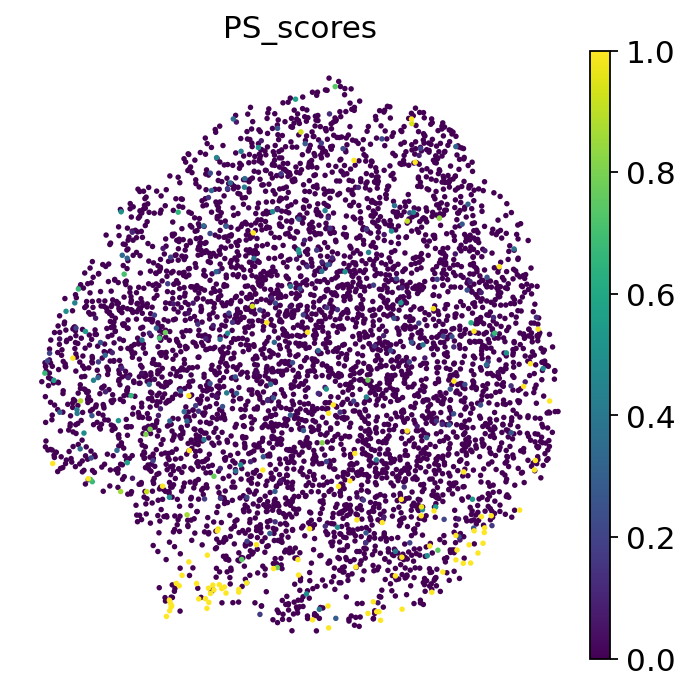

In [73]:
adata_eva.obs['ps_pred_next']=adata_eva.obsm['ps_pred_next']
adata_eva.obs['PS_scores']=adata_eva.obsm['PS_scores']['CTNNB1']
with plt.rc_context({"figure.figsize": (5, 5)}):
  sc.pl.umap(adata_eva[adata_eva.obs.genotype_next!='WT'], color=[ "ps_pred_next",],frameon=False,)
  sc.pl.umap(adata_eva[adata_eva.obs.genotype_next!='WT'], color=[ "genotype_report",],frameon=False,)
  sc.pl.umap(adata_eva[adata_eva.obs.genotype_next!='WT'], color=[ "PS_scores"],frameon=False,)

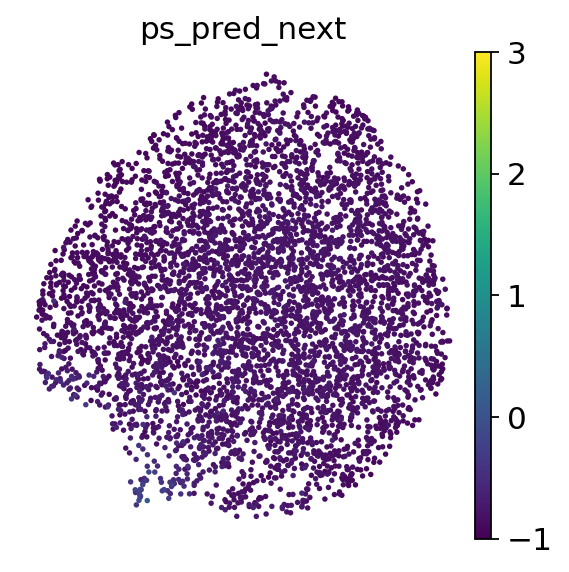

In [74]:
sc.pl.umap(adata_eva[adata_eva.obs.genotype_next!='WT'], color=[ "ps_pred_next",],frameon=False,vmin=-1, vmax=3)

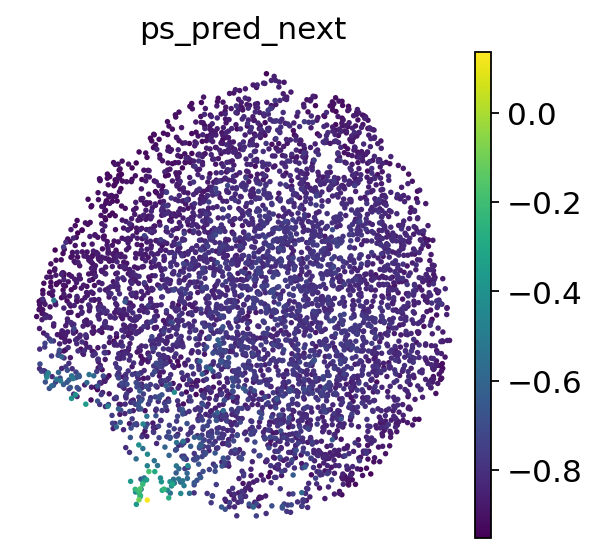

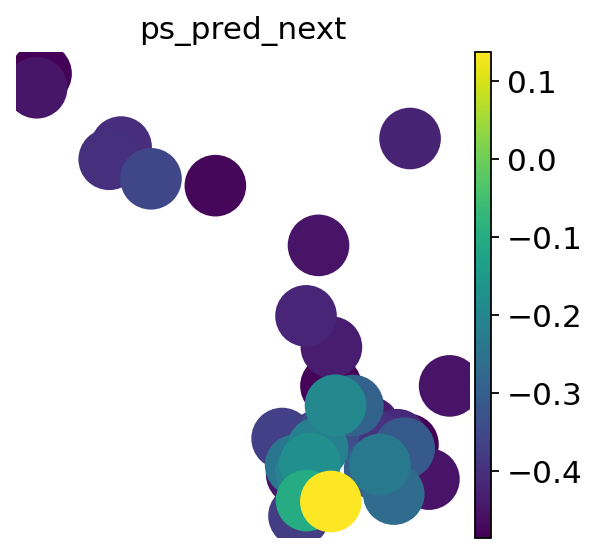

In [75]:
adata_eva_de=adata_eva[adata_eva.obs.genotype_next!='WT']
sc.pl.umap(adata_eva_de, color=[ "ps_pred_next",],frameon=False,)
sc.pl.umap(adata_eva_de[adata_eva_de.obs.ps_pred_next > -0.5], color=[ "ps_pred_next",],frameon=False,)

In [76]:
if 'CTNNB1' in adata_testrun.var_names:
    # Extract CTNNB1 expression for the cells in adata_eva_de
    # Assuming the expression is in .X and might be sparse, convert to dense array
    ctnnb1_expression = adata_testrun[adata_eva_de.obs_names, 'CTNNB1'].X.toarray().flatten()

    # Add as a new column to adata_eva_de.obs
    adata_eva_de.obs['CTNNB1_expression'] = ctnnb1_expression

    print(" 'CTNNB1_expression' column added to adata_eva_de.obs")
    print(adata_eva_de.obs[['genotype_next', 'CTNNB1_expression']].head())
else:
    print("Gene 'CTNNB1' not found in adata_eva_de.var_names.")

 'CTNNB1_expression' column added to adata_eva_de.obs
                        genotype_next  CTNNB1_expression
S1L1_AAACCCAAGACGATAT-1        CTNNB1           0.345784
S1L1_AAACCCAAGATCGGTG-1        CTNNB1           0.000000
S1L1_AAACCCAGTACAGTAA-1        CTNNB1           0.000000
S1L1_AAACGAAGTATCATGC-1        CTNNB1           0.000000
S1L1_AAACGAAGTGATTAGA-1        CTNNB1           0.000000


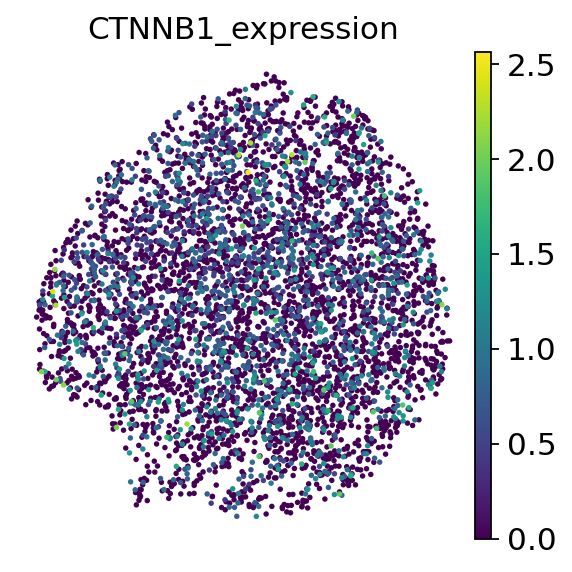

In [77]:
sc.pl.umap(adata_eva_de, color=[ "CTNNB1_expression",],frameon=False,)


#### GSEA analysis of high CTNNB1-perturbed cells

You will see CTNNB1-related pathways but that's not surprising: because we included some of the actual CTNNB1-perturbed cells (although they are masked). But it will be a good sanity check.

In [78]:
import scanpy as sc
import gseapy as gp
import numpy as np
import pandas as pd

# 1. Group cells based on ps_pred_next value
adata_eva_de.obs['group'] = np.where(adata_eva_de.obs['ps_pred_next'] > -0.5, 'group1', 'group2') # cutoff: -0.5

# 2. Perform differential expression using scanpy
# Using 't-test' (or 'wilcoxon')
sc.tl.rank_genes_groups(adata_eva_de, 'group', groups=['group1'], reference='group2', method='wilcoxon')

# Extract DE results into a DataFrame
result_pred = adata_eva_de.uns['rank_genes_groups']
groups_pred = result_pred['names'].dtype.names
diff_exp_df_pred = pd.DataFrame(
    {
        'names': result_pred['names'][groups_pred[0]],
        'scores': result_pred['scores'][groups_pred[0]],
        'pvals': result_pred['pvals'][groups_pred[0]],
        'pvals_adj': result_pred['pvals_adj'][groups_pred[0]],
        'logfoldchanges': result_pred['logfoldchanges'][groups_pred[0]]
    }
)

# 3. Identify top highly expressed genes (e.g., top 200 by score)
top_genes_pred = diff_exp_df_pred.sort_values('scores', ascending=False).head(200)['names'].tolist()
print(f"Top 10 DE genes: {top_genes_pred[:10]}")

# 4. Run GSEA analysis
# Ensure gseapy is installed: !pip install gseapy
# Using Enrichr for the top gene set
enr_pred = gp.enrichr(gene_list=top_genes_pred,
                 gene_sets=['KEGG_2019_Human', 'GO_Biological_Process_2021'],
                 organism='human',
                 outdir=None)

# Display top enriched pathways
enr_pred.results.head(10)


Top 10 DE genes: ['LEFTY1', 'VIM', 'NTS', 'LDLRAD4', 'ROBO2', 'ARHGAP29', 'SIPA1L2', 'THY1', 'TUBA1B', 'LEFTY2']


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2019_Human,Hippo signaling pathway,8/160,0.000212,0.026745,0,0,5.385965,45.559151,MOB1B;FRMD6;SMAD3;FZD2;CCND1;ID1;ACTB;ACTG1
1,KEGG_2019_Human,TGF-beta signaling pathway,6/90,0.000288,0.026745,0,0,7.259205,59.191634,LEFTY1;SMAD3;ID1;ID3;PITX2;LEFTY2
2,KEGG_2019_Human,Glioma,5/75,0.000931,0.040046,0,0,7.227106,50.438854,CDK6;CCND1;CAMK4;PDGFB;CALML4
3,KEGG_2019_Human,Pathways in cancer,14/530,0.000933,0.040046,0,0,2.812953,19.627417,JUN;FZD2;SMAD3;LPAR1;PDGFB;CALML4;GNG11;NFKBIA...
4,KEGG_2019_Human,Wnt signaling pathway,7/158,0.001076,0.040046,0,0,4.719590,32.253897,SFRP1;JUN;SMAD3;FZD2;CCND1;PRICKLE1;CXXC4
5,KEGG_2019_Human,Human cytomegalovirus infection,8/225,0.001972,0.045171,0,0,3.760177,23.420270,NFKBIA;CDK6;CCND1;ITGAV;CALML4;B2M;GNG11;CREB5
6,KEGG_2019_Human,Relaxin signaling pathway,6/130,0.001982,0.045171,0,0,4.907549,30.541899,NFKBIA;JUN;EDNRB;SMAD3;GNG11;CREB5
7,KEGG_2019_Human,Pathogenic Escherichia coli infection,4/55,0.002222,0.045171,0,0,7.902761,48.280112,TUBB6;TUBA1B;ACTB;ACTG1
8,KEGG_2019_Human,Kaposi sarcoma-associated herpesvirus infection,7/186,0.002727,0.045171,0,0,3.975656,23.474660,NFKBIA;JUN;CDK6;CCND1;PDGFB;CALML4;GNG11
9,KEGG_2019_Human,Fluid shear stress and atherosclerosis,6/139,0.002773,0.045171,0,0,4.573366,26.927194,JUN;PDGFB;ITGAV;CALML4;ACTB;ACTG1


In [79]:
diff_exp_df_pred

,names,scores,pvals,pvals_adj,logfoldchanges
0,LEFTY1,6.703977,2.028229e-11,7.804626e-08,5.801017
1,VIM,3.723783,1.962595e-04,5.034710e-02,2.944942
2,NTS,3.597992,3.206835e-04,6.855501e-02,3.024791
3,LDLRAD4,2.980363,2.879068e-03,3.573759e-01,3.059234
4,ROBO2,2.541595,1.103480e-02,8.325867e-01,0.575889
...,...,...,...,...,...
3843,ADAMTS19,-4.321023,1.553078e-05,8.711663e-03,-1.727042
3844,MAGI2,-4.409603,1.035602e-05,7.969994e-03,-1.593571
3845,FAT3,-4.455253,8.379442e-06,7.969994e-03,-1.394531
3846,HDAC2-AS2,-4.752428,2.009882e-06,2.578008e-03,-1.715710


In [80]:
enr_pred.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2019_Human,Hippo signaling pathway,8/160,0.000212,0.026745,0,0,5.385965,45.559151,MOB1B;FRMD6;SMAD3;FZD2;CCND1;ID1;ACTB;ACTG1
1,KEGG_2019_Human,TGF-beta signaling pathway,6/90,0.000288,0.026745,0,0,7.259205,59.191634,LEFTY1;SMAD3;ID1;ID3;PITX2;LEFTY2
2,KEGG_2019_Human,Glioma,5/75,0.000931,0.040046,0,0,7.227106,50.438854,CDK6;CCND1;CAMK4;PDGFB;CALML4
3,KEGG_2019_Human,Pathways in cancer,14/530,0.000933,0.040046,0,0,2.812953,19.627417,JUN;FZD2;SMAD3;LPAR1;PDGFB;CALML4;GNG11;NFKBIA...
4,KEGG_2019_Human,Wnt signaling pathway,7/158,0.001076,0.040046,0,0,4.719590,32.253897,SFRP1;JUN;SMAD3;FZD2;CCND1;PRICKLE1;CXXC4
...,...,...,...,...,...,...,...,...,...,...
1750,GO_Biological_Process_2021,regulation of cellular macromolecule biosynthe...,2/468,0.949944,0.952372,0,0,0.419084,0.021521,DENND4A;ZNF114
1751,GO_Biological_Process_2021,cilium assembly (GO:0060271),1/314,0.958449,0.960286,0,0,0.312858,0.013277,GSN
1752,GO_Biological_Process_2021,positive regulation of cytokine production (GO...,1/335,0.966472,0.967706,0,0,0.292872,0.009988,SULF1
1753,GO_Biological_Process_2021,protein transport (GO:0015031),1/369,0.976322,0.976945,0,0,0.265348,0.006359,STXBP1


In [81]:
enr_pred.results[enr_pred.results['Adjusted P-value']<0.01]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes


In [82]:
enr.results[enr.results['Term'].isin(enr_pred.results[enr_pred.results['Adjusted P-value']<0.01]['Term'])]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes


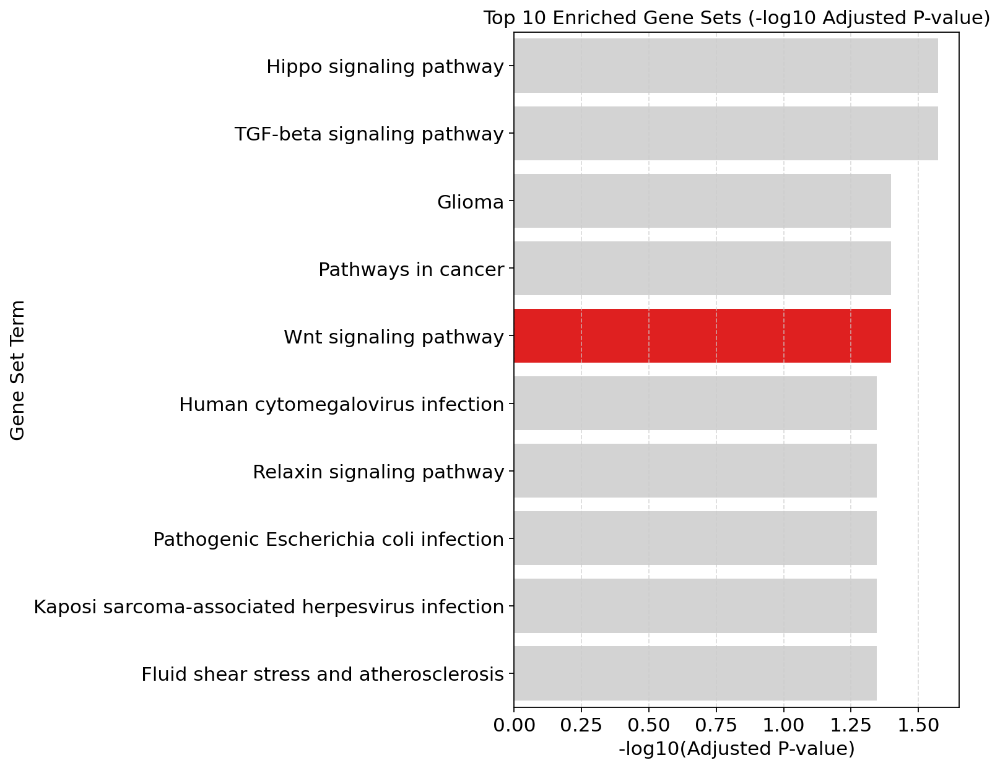

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get top 20 results
plot_df = enr_pred.results.head(10).copy()

# Calculate -log10 Adjusted P-value
plot_df['log_p'] = -np.log10(plot_df['Adjusted P-value'])

# Define target terms for highlighting
target_terms = [
    "Focal adhesion",
    "Regulation of actin cytoskeleton",
    "Axon guidance",
    "Tight junction",
    "Wnt signaling pathway",
    "Adherens junction"
]

# Determine colors: red for targets, grey otherwise
colors = ['red' if term in target_terms else 'lightgrey' for term in plot_df['Term']]

# Create the plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x='log_p',
    y='Term',
    data=plot_df,
    palette=colors,
    hue='Term',
    legend=False
)

plt.title('Top 10 Enriched Gene Sets (-log10 Adjusted P-value)')
plt.xlabel('-log10(Adjusted P-value)')
plt.ylabel('Gene Set Term')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [84]:
overlap_list=[x for x in top_genes_pred if x in top_genes]
len(overlap_list)

68

In [85]:
adata_eva_de[adata_eva_de.obs.ps_pred_next>-0.5].obs.genotype_report.value_counts()

,count
genotype_report,
non-target,23
CTNNB1,16


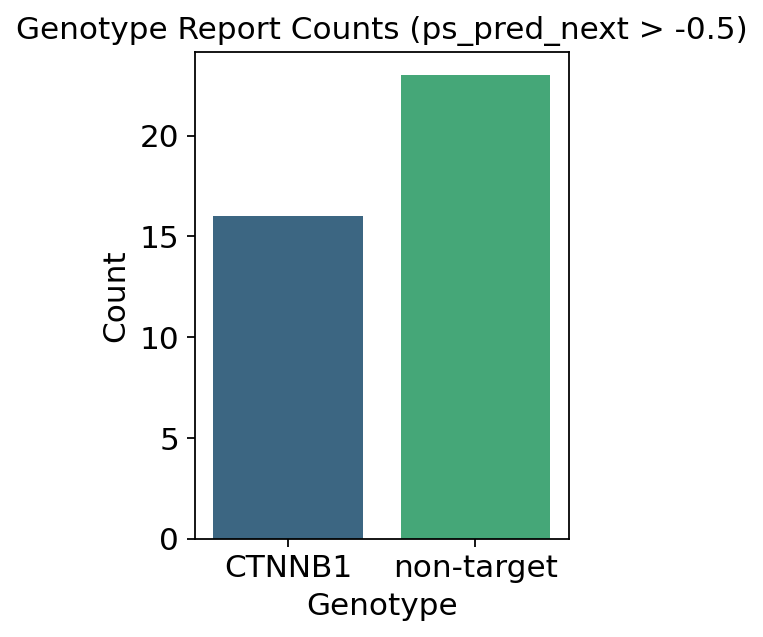

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate counts for the specified subset
subset_counts = adata_eva_de[adata_eva_de.obs.ps_pred_next > -0.5].obs['genotype_report'].value_counts()

# Create the barplot
plt.figure(figsize=(3, 4))
sns.barplot(x=subset_counts.index, y=subset_counts.values, hue=subset_counts.index, palette='viridis', legend=False)

plt.title('Genotype Report Counts (ps_pred_next > -0.5)')
plt.xlabel('Genotype')
plt.ylabel('Count')
plt.grid(False)
plt.show()

In [87]:
adata_eva_de2=adata_eva_de[(adata_eva_de.obs.genotype_next!='WT')]
#adata_eva_de2.obs['PS_scores']=adata_eva_de2.obsm['PS_scores']['CTNNB1']

adata_eva_de2=adata_eva_de2[(adata_eva_de2.obs.genotype_report!='CTNNB1') | (adata_eva_de2.obs.PS_scores > 0.5)]

adata_eva_de2.obs.genotype_report.value_counts()

,count
genotype_report,
non-target,4395
CTNNB1,134


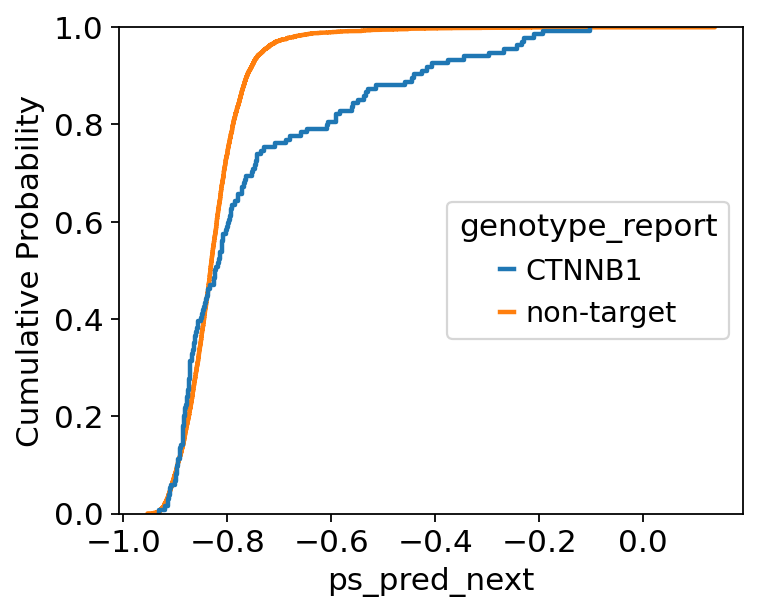

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
ax=sns.ecdfplot(data=adata_eva_de2.obs, x='ps_pred_next', hue='genotype_report',linewidth=2)
sns.move_legend(ax, loc='center right')
#plt.title('Cumulative Distribution of ps_pred_next by Genotype Report')
plt.xlabel('ps_pred_next')
plt.ylabel('Cumulative Probability')
# Removed explicit plt.legend() call to allow seaborn to handle it automatically
#plt.legend(loc='center right')
plt.grid(False)
plt.show()

In [89]:
adata_eva_de2.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_Custom,nFeature_Custom,percent.mt,doublet_score,is_doublet_0.08,is_doublet_0.10,is_doublet_0.15,...,lonESS_score_FOXA2,lonESS_score_NEUROD1,lonESS_score_PAX6,lonESS_score_PBX1,lonESS_score_TADA2B,lonESS_score_TLE3,ps_pred_next,PS_scores,CTNNB1_expression,group
S1L1_AAACCCAAGACGATAT-1,S1L1,10552.0,4380,135.0,30,5.335481,0.392972,False,False,False,...,-0.395020,0.421875,-0.438965,-1.046875,-0.896484,-0.203247,-0.816406,0.0,0.345784,group2
S1L1_AAACCCAAGATCGGTG-1,S1L1,4259.0,2430,10.0,10,5.376849,0.143777,False,False,False,...,7.078125,-0.636719,-0.704590,-1.225586,-1.006836,-0.946777,-0.891602,0.0,0.000000,group2
S1L1_AAACCCAGTACAGTAA-1,S1L1,4639.0,2426,298.0,39,5.777107,0.122401,False,False,False,...,0.806641,0.212036,-0.412598,-1.050781,-0.826172,-0.073425,-0.799805,0.0,0.000000,group2
S1L1_AAACGAAGTATCATGC-1,S1L1,5392.0,2821,15.0,15,6.175816,0.151391,False,False,False,...,-0.048828,-0.224243,-0.471436,-0.351074,-0.204224,-0.416016,-0.904297,0.0,0.000000,group2
S1L1_AAACGAAGTGATTAGA-1,S1L1,2845.0,1734,38.0,16,7.416520,0.093704,False,False,False,...,2.222656,-0.202026,-0.500977,-0.790039,-0.695312,-0.468262,-0.896973,0.0,0.000000,group2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S2L2_TTTGGAGGTGTGTGTT-1,S2L2,6231.0,3080,519.0,31,6.531857,0.236412,False,False,False,...,-0.006592,0.095215,-0.421387,-0.937988,-0.818359,-0.141724,-0.800293,0.0,0.530373,group2
S2L2_TTTGGTTAGCGAGTAC-1,S2L2,799.0,613,25.0,23,15.269086,0.009763,False,False,False,...,0.133057,-0.266357,-0.217651,0.419922,0.334473,-0.538574,-0.856934,0.0,0.000000,group2
S2L2_TTTGGTTGTACGTGTT-1,S2L2,3581.0,2031,411.0,25,9.271153,0.101055,False,False,False,...,-0.087585,0.116577,-0.552734,-0.295898,-0.342773,-0.169922,-0.740723,0.0,0.000000,group2
S2L2_TTTGGTTTCGAGAATA-1,S2L2,4663.0,2622,223.0,23,6.347845,0.153298,False,False,False,...,1.320312,0.053802,-0.390381,-0.764160,-0.553711,-0.296875,-0.804688,0.0,0.660007,group2


In [90]:
from scipy.stats import ks_2samp

# Extract ps_pred_next for 'non-target' and 'CTNNB1' groups
non_target_scores = adata_eva_de2.obs.loc[adata_eva_de2.obs['genotype_report'] == 'non-target', 'ps_pred_next']
ctnnb1_scores = adata_eva_de2.obs.loc[adata_eva_de2.obs['genotype_report'] == 'CTNNB1', 'ps_pred_next']

# Perform Kolmogorov-Smirnov test
ks_statistic, p_value = ks_2samp(non_target_scores, ctnnb1_scores)

print(f"Kolmogorov-Smirnov test p-value between 'non-target' and 'CTNNB1' groups: {p_value:.3e}")

Kolmogorov-Smirnov test p-value between 'non-target' and 'CTNNB1' groups: 1.971e-06


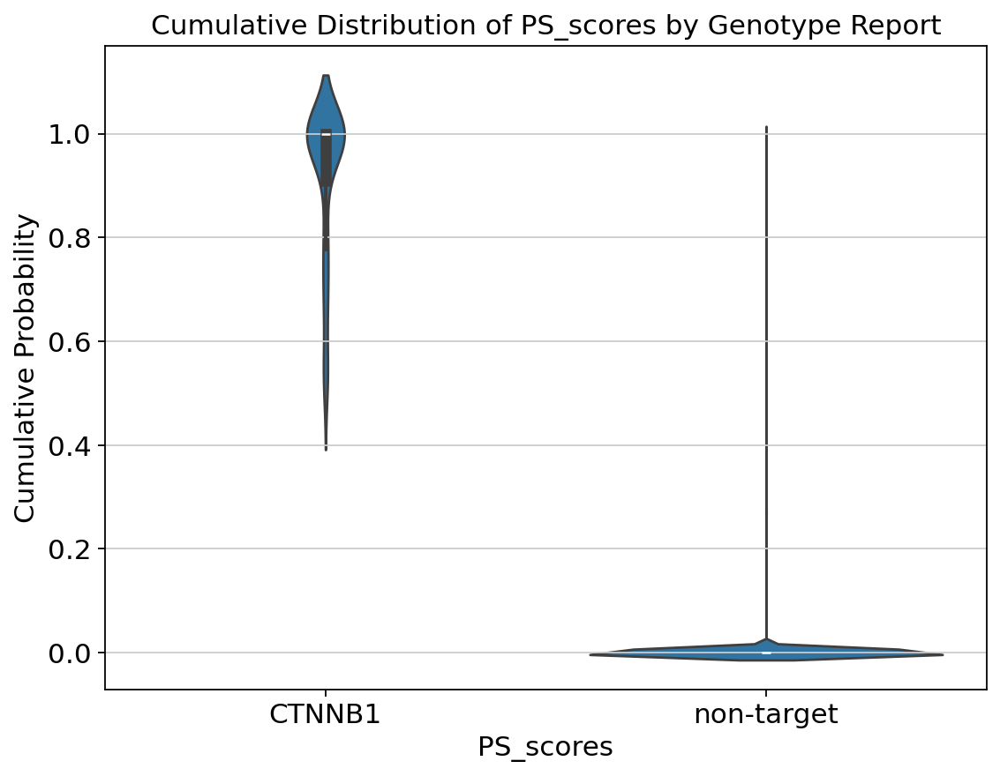

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax=sns.violinplot(data=adata_eva_de2.obs, y='PS_scores', x='genotype_report')
#sns.move_legend(ax, loc='center right')
plt.title('Cumulative Distribution of PS_scores by Genotype Report')
plt.xlabel('PS_scores')
plt.ylabel('Cumulative Probability')
# Removed explicit plt.legend() call to allow seaborn to handle it automatically
#plt.legend(loc='center right')
plt.show()

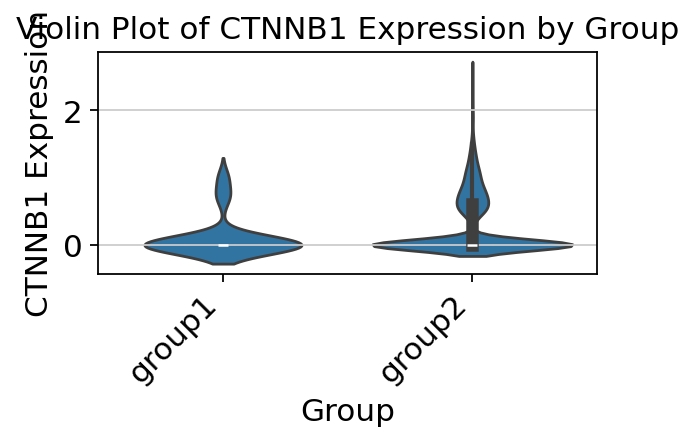

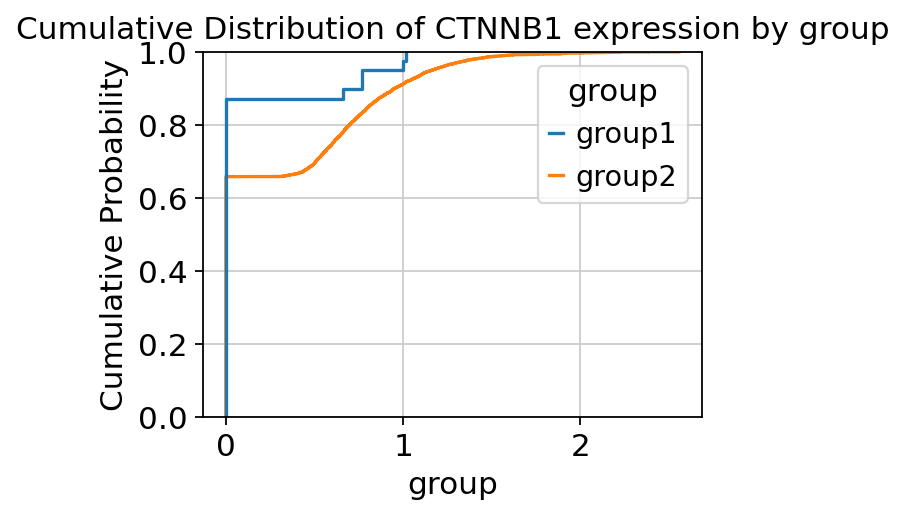

Kolmogorov-Smirnov test p-value between group1 and group2: 4.913e-02


In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ks_2samp

# Ensure 'CTNNB1_expression' exists and 'group' column is defined
if 'CTNNB1_expression' in adata_eva_de2.obs.columns and 'group' in adata_eva_de2.obs.columns:
    # Create a pandas DataFrame for plotting
    plot_data = pd.DataFrame({
        'CTNNB1_expression': adata_eva_de2.obs['CTNNB1_expression'],
        'group': adata_eva_de2.obs['group']
    })

    # Generate the violin plot
    plt.figure(figsize=(4, 3))
    sns.violinplot(x='group', y='CTNNB1_expression', data=plot_data, inner='box')
    plt.title('Violin Plot of CTNNB1 Expression by Group')
    plt.xlabel('Group')
    plt.ylabel('CTNNB1 Expression')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(4, 3))
    sns.ecdfplot(data=plot_data, x='CTNNB1_expression', hue='group')
    plt.title('Cumulative Distribution of CTNNB1 expression by group')
    plt.xlabel('group')
    plt.ylabel('Cumulative Probability')
    # Removed explicit plt.legend() call to allow seaborn to handle it automatically
    plt.show()

    # Extract data for KS test
    group1_data = plot_data[plot_data['group'] == 'group1']['CTNNB1_expression']
    group2_data = plot_data[plot_data['group'] == 'group2']['CTNNB1_expression']

    # Perform Kolmogorov-Smirnov test
    ks_statistic, p_value = ks_2samp(group1_data, group2_data)
    print(f"Kolmogorov-Smirnov test p-value between group1 and group2: {p_value:.3e}")
else:
    print("Either 'CTNNB1_expression' or 'group' column is missing in adata_eva_de.obs. Please ensure they are created.")


### plot the cell embeddings

In [93]:
adata_eva

AnnData object with n_obs × n_vars = 9758 × 3848
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Custom', 'nFeature_Custom', 'percent.mt', 'doublet_score', 'is_doublet_0.08', 'is_doublet_0.10', 'is_doublet_0.15', 'genotype', 'genotype_umis', 'gRNA_detectedGenes', 'genotype_report', 'celltype', 'mixscape_class_global', 'genotype_next', 'predicted_genotype', 'genotype_id', 'predicted_celltype', 'celltype_id', 'lonESS_score_NEUROG3', 'lonESS_score_HHEX', 'lonESS_score_RFX6', 'lonESS_score_GATA4', 'lonESS_score_GATA6', 'lonESS_score_FOXA2', 'lonESS_score_NEUROD1', 'lonESS_score_PAX6', 'lonESS_score_PBX1', 'lonESS_score_TADA2B', 'lonESS_score_TLE3', 'ps_pred_next', 'PS_scores'
    var: 'names', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'neighbors', 'umap', 'predicted_celltype_colors', 'celltype_colors', 'genotype_colors', 'genotype_next_colors'
    obsm: 'PS_scores', 'X_scGPT', 'X_scGPT_next', 'ps_pred', 'ps_pred_next', 'X_pert_pred_probs', '

In [94]:
adata_eva_copy=adata_eva #.copy()
adata_eva_copy.obs['genotype'] = adata_eva_copy.obs['genotype'].cat.add_categories('CTNNB1')
adata_eva_copy.obs.loc[adata_eva_copy.obs['genotype_report']=='CTNNB1','genotype']='CTNNB1'

sc.pp.neighbors(adata_eva_copy, use_rep="X_scGPT_next")
sc.tl.umap(adata_eva_copy, min_dist=0.3)

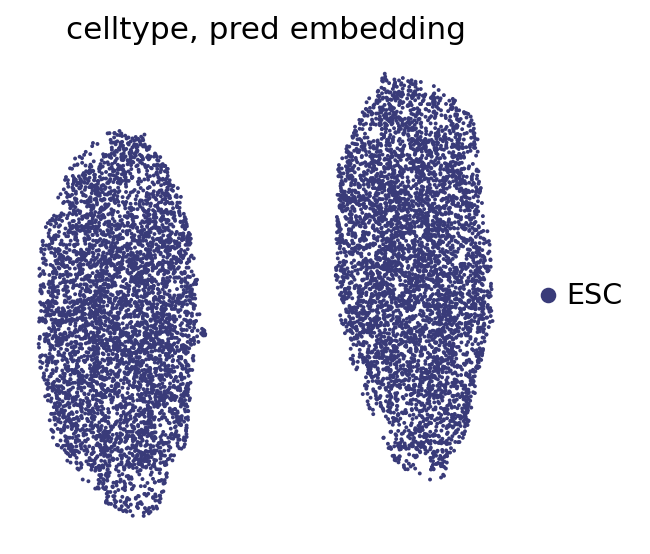

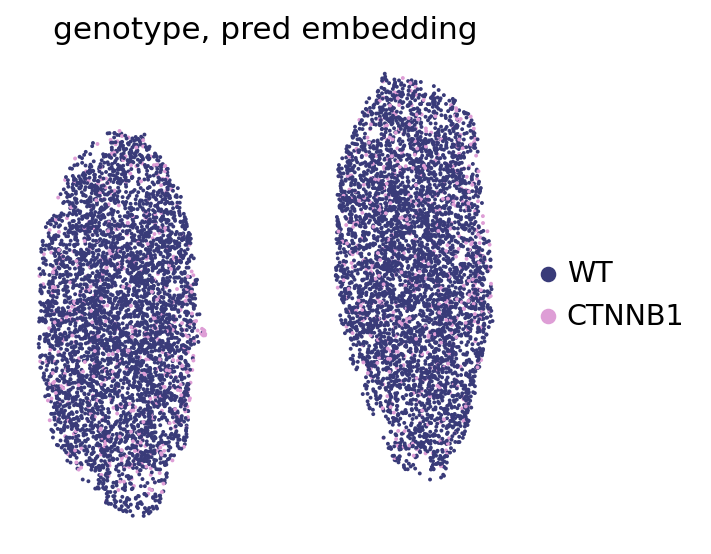

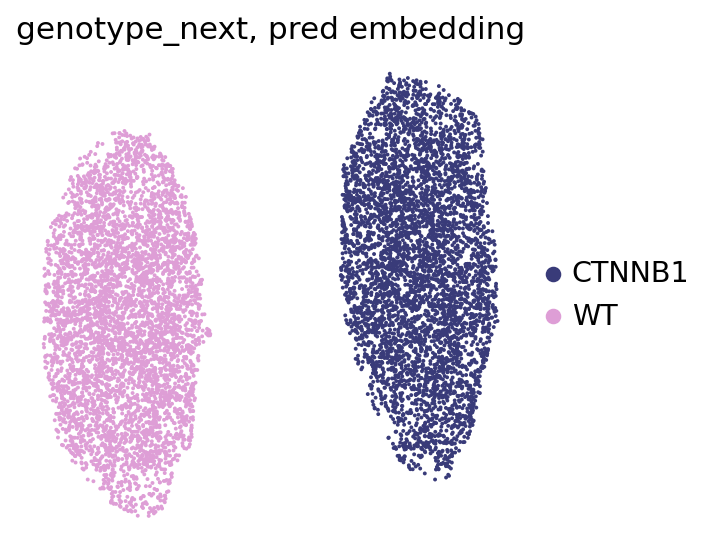

In [95]:
sc.pl.umap(adata_eva_copy, color=["celltype"],
    title=[f"celltype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)
sc.pl.umap(adata_eva_copy, color=["genotype"],
    title=[f"genotype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)


sc.pl.umap(adata_eva_copy, color=["genotype_next"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)

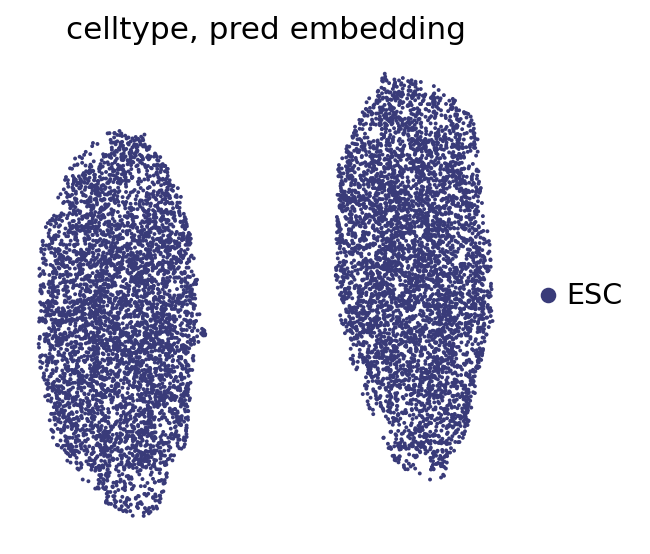

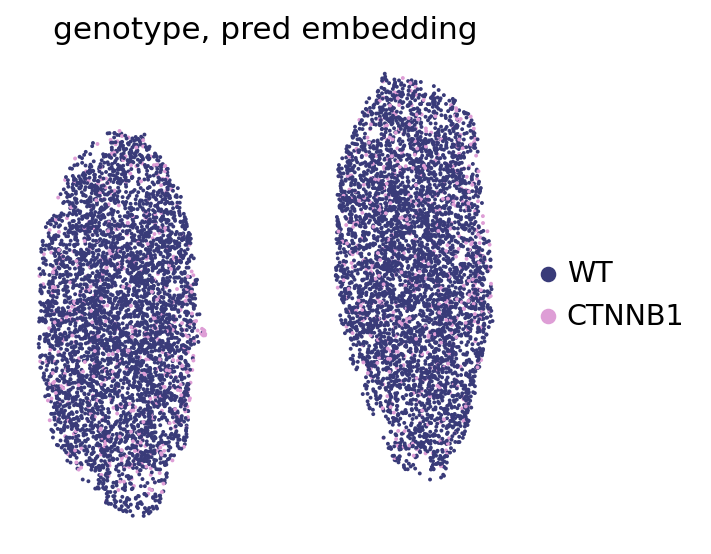

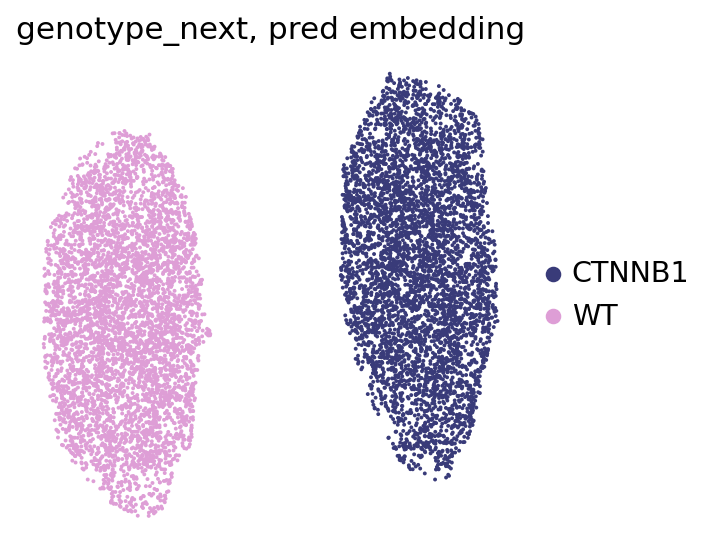

In [96]:
adata_eva_copy2=adata_eva_copy[adata_eva_copy.obs['genotype'].isin(['WT',target_pred_gene])]
adata_eva_copy2
sc.pl.umap(adata_eva_copy2, color=["celltype"],
    title=[f"celltype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)
sc.pl.umap(adata_eva_copy2, color=["genotype"],
    title=[f"genotype, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)


sc.pl.umap(adata_eva_copy2, color=["genotype_next"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)

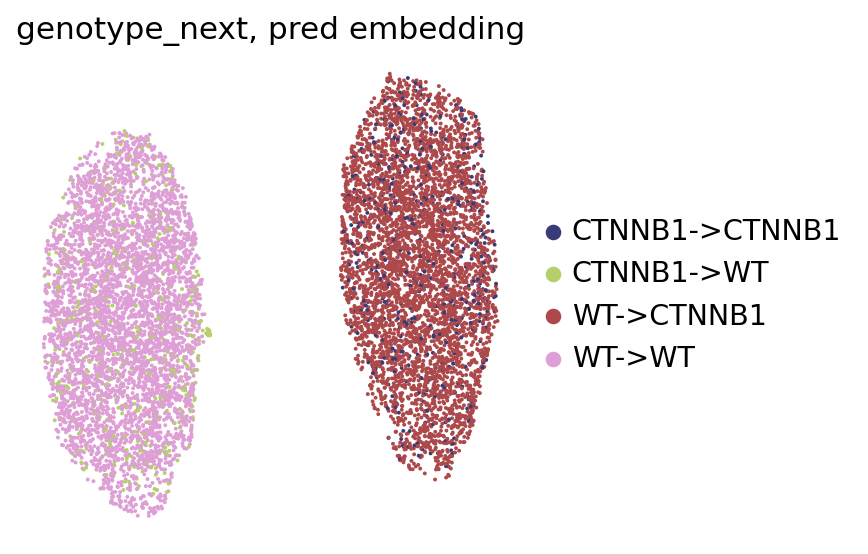

In [97]:
# prompt: concatenate both genotype and genotype_next columns of adata_eva_copy2.obs into a new column named "genotype_combined"

adata_eva_copy2.obs["genotype_combined"] = adata_eva_copy2.obs["genotype"].astype(str) + "->" + adata_eva_copy2.obs["genotype_next"].astype(str)
sc.pl.umap(adata_eva_copy2, color=["genotype_combined"],
    title=[f"genotype_next, pred embedding",],
    frameon=False,
    return_fig=False,
    palette="tab20b",
    #show=False,
)

In [98]:
adata_eva_copy2.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_Custom,nFeature_Custom,percent.mt,doublet_score,is_doublet_0.08,is_doublet_0.10,is_doublet_0.15,...,lonESS_score_GATA6,lonESS_score_FOXA2,lonESS_score_NEUROD1,lonESS_score_PAX6,lonESS_score_PBX1,lonESS_score_TADA2B,lonESS_score_TLE3,ps_pred_next,PS_scores,genotype_combined
S1L1_AAACCCAAGACGATAT-1,S1L1,10552.0,4380,135.0,30,5.335481,0.392972,False,False,False,...,2.234375,-0.395020,0.421875,-0.438965,-1.046875,-0.896484,-0.203247,-0.816406,0.000000,WT->CTNNB1
S1L1_AAACCCAAGATCGGTG-1,S1L1,4259.0,2430,10.0,10,5.376849,0.143777,False,False,False,...,0.741211,7.078125,-0.636719,-0.704590,-1.225586,-1.006836,-0.946777,-0.891602,0.000000,WT->CTNNB1
S1L1_AAACCCAGTACAGTAA-1,S1L1,4639.0,2426,298.0,39,5.777107,0.122401,False,False,False,...,1.691406,0.806641,0.212036,-0.412598,-1.050781,-0.826172,-0.073425,-0.799805,0.000000,WT->CTNNB1
S1L1_AAACCCATCATTTCGT-1,S1L1,3949.0,2255,263.0,19,1.595341,0.127965,False,False,False,...,3.357422,0.043854,-0.014893,-0.411621,-0.817871,-0.678711,-0.256592,-1.019531,0.223116,CTNNB1->WT
S1L1_AAACGAACACCCTTAC-1,S1L1,4413.0,2705,77.0,17,1.427600,0.438360,False,False,True,...,3.423828,-0.266113,0.841797,-0.476318,-1.259766,-1.146484,-0.406738,-1.007812,0.000000,WT->WT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S2L2_TTTGGTTTCAACTACG-1,S2L2,3765.0,2267,487.0,32,4.701195,0.175989,False,False,False,...,1.361328,-0.069275,0.120178,-0.385254,-0.543945,-0.383057,-0.178345,-1.025391,0.000000,WT->WT
S2L2_TTTGGTTTCAAGTCGT-1,S2L2,1546.0,1035,27.0,14,18.822768,0.014512,False,False,False,...,1.361328,0.040405,0.072083,-0.429443,-0.527832,-0.463867,-0.225708,-1.014648,0.000000,WT->WT
S2L2_TTTGGTTTCGAGAATA-1,S2L2,4663.0,2622,223.0,23,6.347845,0.153298,False,False,False,...,1.333008,1.320312,0.053802,-0.390381,-0.764160,-0.553711,-0.296875,-0.804688,0.000000,WT->CTNNB1
S2L2_TTTGTTGAGCTACGTT-1,S2L2,4410.0,2605,635.0,41,2.403628,0.295778,False,False,False,...,2.513672,-0.064514,0.334961,-0.436523,-1.195312,-1.023438,-0.039276,-1.015625,0.000000,WT->WT


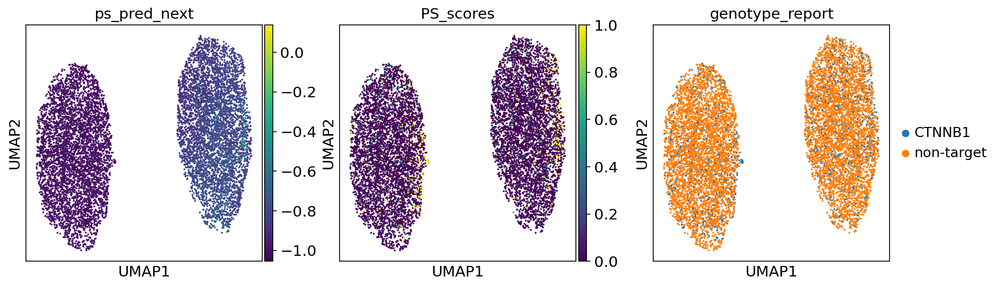

In [99]:
sc.pl.umap(adata_eva_copy2, color=["ps_pred_next","PS_scores",'genotype_report'],

)